## Setup & Configuration

In [6]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from datetime import timezone, timedelta

warnings.filterwarnings("ignore")

# Configuration
BASE_DIR = Path(".").resolve()
print (f"Base directory: {BASE_DIR}")
SENSOR_DATA_DIR = BASE_DIR.parent.parent / "store" / "data" / "raw" / "sensor_data"
OUT_DIR = BASE_DIR / "eda_outputs"

# specific constants
CDT             = timezone(timedelta(hours=-5))  # Central Daylight Time
COWS            = [f"T{i:02d}" for i in range(1, 11)]  # T01–T10 (tracked cows)

# environment setup
os.makedirs(OUT_DIR, exist_ok=True)

# Plotting defaults
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

print(f"Config:")
print(f"  Sensor dir: {SENSOR_DATA_DIR}")
print(f"  Output dir: {OUT_DIR}")
print(f"  Timezone: {CDT}")
print(f"  Number of Tracked cows: {len(COWS)}")
print(f"  Tracked cows: {COWS}")

Base directory: /home/haythem/vscode/pfa-mmcows/exploration/sensor
Config:
  Sensor dir: /home/haythem/vscode/pfa-mmcows/store/data/raw/sensor_data
  Output dir: /home/haythem/vscode/pfa-mmcows/exploration/sensor/eda_outputs
  Timezone: UTC-05:00
  Number of Tracked cows: 10
  Tracked cows: ['T01', 'T02', 'T03', 'T04', 'T05', 'T06', 'T07', 'T08', 'T09', 'T10']


In [7]:

# Quick test: verify environment is working
print("✓ Libraries imported successfully")
print(f"  NumPy: {np.__version__}")
print(f"  Pandas: {pd.__version__}")
print(f"  Matplotlib: {plt.matplotlib.__version__}")


✓ Libraries imported successfully
  NumPy: 2.2.6
  Pandas: 2.3.3
  Matplotlib: 3.10.8


In [8]:

# DIAGNOSTIC: Check what files actually exist
print("=" * 70)
print("DIAGNOSTIC: Checking data folder structure")
print("=" * 70)

# Check each modality folder
modalities = ["cbt", "ankle", "thi", "weather", "milk", "uwb"]
for mod in modalities:
    mod_path = os.path.join(SENSOR_DATA_DIR, "main_data", mod)
    if os.path.exists(mod_path):
        items = os.listdir(mod_path)
        print(f"\n✓ {mod.upper()}: exists")
        print(f"  Path: {mod_path}")
        print(f"  Contents ({len(items)} items):")
        for item in items[:5]:  # Show first 5
            full_path = os.path.join(mod_path, item)
            if os.path.isdir(full_path):
                sub_items = os.listdir(full_path)
                print(f"    📁 {item}/ ({len(sub_items)} files)")
                for sub in sub_items[:2]:  # Show first 2 sub-files
                    print(f"       - {sub}")
            else:
                print(f"    📄 {item}")
        if len(items) > 5:
            print(f"    ... and {len(items) - 5} more")
    else:
        print(f"\n✗ {mod.upper()}: NOT FOUND")
        print(f"  Path: {mod_path}")

print("\n" + "=" * 70)


DIAGNOSTIC: Checking data folder structure

✓ CBT: exists
  Path: /home/haythem/vscode/pfa-mmcows/store/data/raw/sensor_data/main_data/cbt
  Contents (10 items):
    📄 C05.csv
    📄 C01.csv
    📄 C07.csv
    📄 C08.csv
    📄 C03.csv
    ... and 5 more

✓ ANKLE: exists
  Path: /home/haythem/vscode/pfa-mmcows/store/data/raw/sensor_data/main_data/ankle
  Contents (10 items):
    📁 C02/ (15 files)
       - C02_0727.csv
       - C02_0729.csv
    📁 C07/ (15 files)
       - C07_0723.csv
       - C07_0721.csv
    📁 C10/ (15 files)
       - C10_0802.csv
       - C10_0727.csv
    📁 C09/ (15 files)
       - C09_0726.csv
       - C09_0729.csv
    📁 C03/ (15 files)
       - C03_0730.csv
       - C03_0722.csv
    ... and 5 more

✓ THI: exists
  Path: /home/haythem/vscode/pfa-mmcows/store/data/raw/sensor_data/main_data/thi
  Contents (7 items):
    📄 S02.csv
    📄 S06.csv
    📄 S01.csv
    📄 S04.csv
    📄 S05.csv
    ... and 2 more

✓ WEATHER: exists
  Path: /home/haythem/vscode/pfa-mmcows/store/data/

## Helper Functions

In [9]:
def to_cdt(series: pd.Series) -> pd.Series:
    """Convert unix timestamp column to CDT datetime."""
    return pd.to_datetime(series, unit="s", utc=True).dt.tz_convert(CDT)

def load_csv_folder(folder: str, cow: str) -> pd.DataFrame:
    """Load and concat all CSVs for one cow inside a modality folder."""
    pattern = os.path.join(folder, cow, "*.csv")
    files = sorted(glob.glob(pattern))
    if not files:
        return pd.DataFrame()
    dfs = [pd.read_csv(f) for f in files]
    return pd.concat(dfs, ignore_index=True)

def show_fig(fig, name: str = ""):
    """Display matplotlib figure in notebook."""
    fig.tight_layout()
    plt.show()
    if name:
        print(f"📊 Chart: {name}")

# [1/5] Load Lightweight Modalities

Load: CBT, ankle accelerometer, THI, weather, milk yield, UWB tracking

In [10]:
print("[1/5] Loading lightweight modalities (CBT, ankle, THI, weather, milk)…")

# --- Core Body Temperature (60s interval) ---
# Note: CBT files are C01.csv, C02.csv, etc. (direct files, not in subfolders)
cbt_all = {}
cbt_path = os.path.join(SENSOR_DATA_DIR, "main_data", "cbt")
cbt_files = sorted(glob.glob(os.path.join(cbt_path, "*.csv")))

for filepath in cbt_files:
    cow = os.path.basename(filepath).replace(".csv", "")
    df = pd.read_csv(filepath)
    if not df.empty:
        df.columns = df.columns.str.strip().str.lower()
        ts_col  = [c for c in df.columns if "time" in c or "ts" in c][0] if [c for c in df.columns if "time" in c or "ts" in c] else None
        val_col = [c for c in df.columns if c != ts_col and c not in ["dim"]][0] if ts_col else None
        
        if ts_col and val_col:
            df = df.rename(columns={ts_col: "timestamp", val_col: "cbt"})
            df["datetime"] = to_cdt(df["timestamp"])
            df["cow"] = cow
            cbt_all[cow] = df.sort_values("datetime")
            
cbt_df = pd.concat(cbt_all.values(), ignore_index=True) if cbt_all else pd.DataFrame()
print(f"    CBT rows: {len(cbt_df):,} (from {len(cbt_all)} cows)")

# --- Ankle / Lying (60s interval) ---
# Note: ANKLE has CSV with columns: timestamp, datetime (string), lying
# The CSV already has a datetime column (string format), so we preserve it and parse as CDT
ankle_all = {}
ankle_path = os.path.join(SENSOR_DATA_DIR, "main_data", "ankle")
cow_folders = sorted([d for d in os.listdir(ankle_path) if os.path.isdir(os.path.join(ankle_path, d))])

for cow in cow_folders:
    df = load_csv_folder(ankle_path, cow)
    if not df.empty:
        df.columns = df.columns.str.strip().str.lower()
        # Ankle CSVs have: timestamp (unix), datetime (string), lying (0/1)
        # Convert lying to numeric, keep datetime as-is (already in CDT format)
        if "lying" in df.columns:
            df["lying"] = pd.to_numeric(df["lying"], errors='coerce')
            # Ensure datetime column exists and is parsed correctly
            if "datetime" in df.columns:
                df["datetime"] = pd.to_datetime(df["datetime"], errors='coerce')
            df["cow"] = cow
            ankle_all[cow] = df.sort_values("datetime")
            
ankle_df = pd.concat(ankle_all.values(), ignore_index=True) if ankle_all else pd.DataFrame()
print(f"    Ankle rows: {len(ankle_df):,} (from {len(ankle_all)} cows)")


[1/5] Loading lightweight modalities (CBT, ankle, THI, weather, milk)…
    CBT rows: 197,920 (from 10 cows)
    Ankle rows: 197,920 (from 10 cows)


In [11]:
# --- THI / Indoor Environment (60s interval) ---
thi_path = os.path.join(SENSOR_DATA_DIR, "main_data", "thi")
thi_files = sorted(glob.glob(os.path.join(thi_path, "*.csv")))
if not thi_files:
    thi_files = sorted(glob.glob(os.path.join(thi_path, "**", "*.csv"), recursive=True))

if thi_files:
    thi_df = pd.concat([pd.read_csv(f) for f in thi_files], ignore_index=True)
    thi_df.columns = thi_df.columns.str.strip().str.lower()
    ts_col = [c for c in thi_df.columns if "time" in c or "ts" in c][0]
    thi_df["datetime"] = to_cdt(thi_df[ts_col])
    thi_df = thi_df.sort_values("datetime")
else:
    thi_df = pd.DataFrame()
print(f"    THI rows: {len(thi_df):,}")

# --- Weather (300s interval) ---
# Note: Weather data is in Excel format (.xlsx) with time-only values (no dates)
# We extract date from filename and combine with time
wx_files = sorted(glob.glob(os.path.join(SENSOR_DATA_DIR, "main_data", "weather", "*.xlsx")))
if wx_files:
    wx_dfs = []
    for f in wx_files:
        try:
            df = pd.read_excel(f)
            if not df.empty:
                # Extract date from filename (e.g., "07_21_2023.xlsx" -> "2023-07-21")
                fname = os.path.basename(f).replace(".xlsx", "")
                try:
                    parts = fname.split("_")
                    if len(parts) >= 3:
                        date_str = f"{parts[2]}-{parts[0]}-{parts[1]}"  # YYYY-MM-DD
                        df["_file_date"] = date_str
                except:
                    pass
                wx_dfs.append(df)
        except Exception as e:
            print(f"      Could not read {os.path.basename(f)}: {e}")
    
    if wx_dfs:
        wx_df = pd.concat(wx_dfs, ignore_index=True)
        wx_df.columns = wx_df.columns.str.strip().str.lower()
        
        # Find timestamp column
        ts_col_candidates = [c for c in wx_df.columns if "time" in c or "ts" in c]
        if ts_col_candidates and "_file_date" in wx_df.columns:
            ts_col = ts_col_candidates[0]
            # Combine date (from filename) + time (from data) into full datetime
            try:
                wx_df["datetime_str"] = wx_df["_file_date"] + " " + wx_df[ts_col].astype(str)
                wx_df["datetime"] = pd.to_datetime(wx_df["datetime_str"])
            except:
                # Fallback: use just the timestamp column as-is
                wx_df["datetime"] = pd.to_datetime(wx_df[ts_col], errors="coerce")
            
            if "datetime" in wx_df.columns:
                wx_df = wx_df.sort_values("datetime")
                wx_df = wx_df.drop(columns=["_file_date", "datetime_str"], errors="ignore")
        else:
            print("      Warning: Could not find timestamp or file date in weather data")
    else:
        wx_df = pd.DataFrame()
else:
    wx_df = pd.DataFrame()
print(f"    Weather rows: {len(wx_df):,}")

    THI rows: 138,486
      Could not read 07_21_2023.xlsx: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.
      Could not read 07_22_2023.xlsx: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.
      Could not read 07_23_2023.xlsx: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.
      Could not read 07_24_2023.xlsx: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.
      Could not read 07_25_2023.xlsx: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.
      Could not read 07_26_2023.xlsx: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.
      Could not read 07_27_2023.xlsx: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.
      Could not read 07_28_2023.xlsx: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.
      Could not read 07_29_2023.xlsx: Miss

In [12]:
# --- Milk Yield (daily) ---
milk_all = {}
milk_files = sorted(glob.glob(os.path.join(SENSOR_DATA_DIR, "main_data", "milk", "*.csv")))
if milk_files:
    for f in milk_files:
        cow = os.path.basename(f).replace(".csv", "")
        df = pd.read_csv(f)
        df.columns = df.columns.str.strip().str.lower()
        df["cow"] = cow
        milk_all[cow] = df
    milk_df = pd.concat(milk_all.values(), ignore_index=True) if milk_all else pd.DataFrame()
else:
    milk_df = pd.DataFrame()
print(f"    Milk rows: {len(milk_df):,}")

# --- UWB Location (15s interval) ---
uwb_all = {}
for cow in COWS:
    df = load_csv_folder(os.path.join(SENSOR_DATA_DIR, "main_data", "uwb"), cow)
    if not df.empty:
        df.columns = df.columns.str.strip().str.lower()
        ts_col = [c for c in df.columns if "time" in c or "ts" in c][0]
        df["datetime"] = to_cdt(df[ts_col])
        df["cow"] = cow
        uwb_all[cow] = df.sort_values("datetime")
uwb_df = pd.concat(uwb_all.values(), ignore_index=True) if uwb_all else pd.DataFrame()
print(f"    UWB rows: {len(uwb_df):,}")

print("  ✓ Load complete")

    Milk rows: 240
    UWB rows: 788,608
  ✓ Load complete


# [2/5] Data Quality Checks

Assess data completeness, sampling rates, outliers, sensor drift

[2/5] Data quality checks…


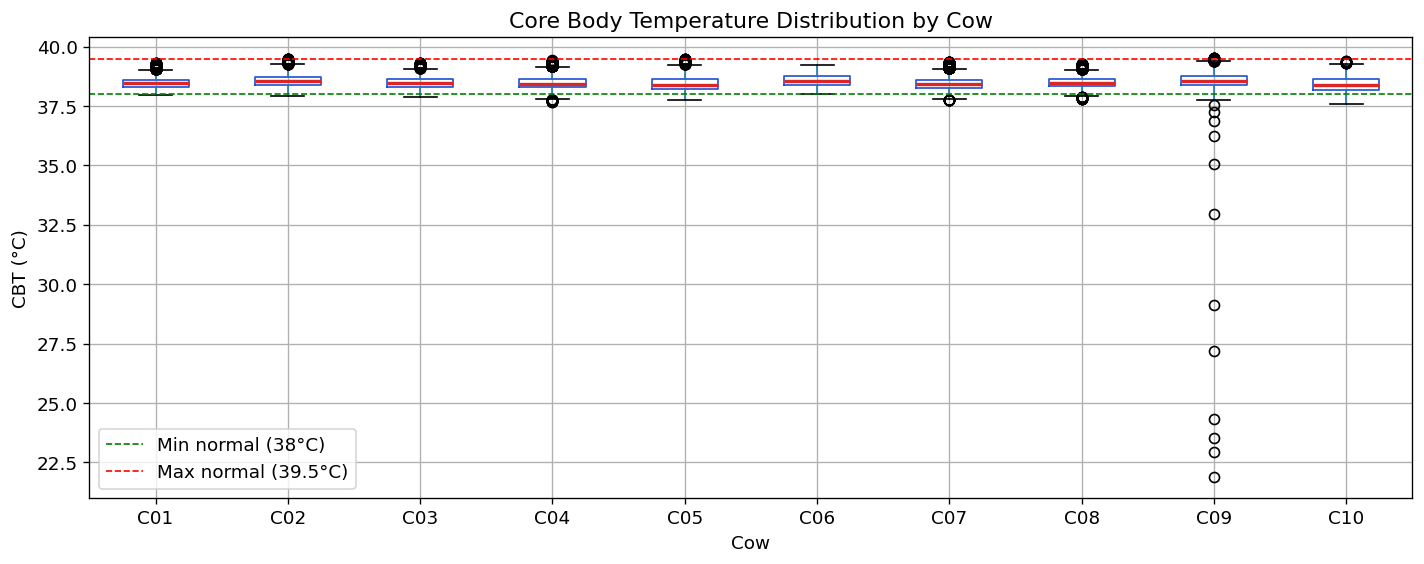

📊 Chart: CBT Outliers Boxplot
    CBT outliers (<36°C or >42°C): 8 rows
    T13 UWB positional std: x=17.541m, y=18.924m ⚠ HIGH DRIFT
    T14 UWB positional std: x=25.312m, y=19.878m ⚠ HIGH DRIFT
  ✓ Quality checks complete


In [14]:
print("[2/5] Data quality checks…")

# CBT Outlier Detection
if not cbt_df.empty:
    fig, ax = plt.subplots(figsize=(12, 5))
    cbt_df.boxplot(column="cbt", by="cow", ax=ax,
                   boxprops=dict(color="#1d4ed8"),
                   medianprops=dict(color="#dc2626", linewidth=2))
    ax.axhline(38.0, color="green", linestyle="--", linewidth=1, label="Min normal (38°C)")
    ax.axhline(39.5, color="red",   linestyle="--", linewidth=1, label="Max normal (39.5°C)")
    ax.set_title("Core Body Temperature Distribution by Cow")
    ax.set_xlabel("Cow")
    ax.set_ylabel("CBT (°C)")
    ax.legend()
    plt.suptitle("")
    show_fig(fig, "CBT Outliers Boxplot")
    outliers = cbt_df[(cbt_df["cbt"] < 36) | (cbt_df["cbt"] > 42)]
    print(f"    CBT outliers (<36°C or >42°C): {len(outliers)} rows")

# UWB stationary tag sanity check (T13, T14 are fixed)
for stat_tag in ["T13", "T14"]:
    df = load_csv_folder(os.path.join(SENSOR_DATA_DIR, "main_data", "uwb"), stat_tag)
    if not df.empty:
        df.columns = df.columns.str.strip().str.lower()
        coord_cols = [c for c in df.columns if c not in ["timestamp", "datetime", "cow"]]
        if len(coord_cols) >= 2:
            x_col, y_col = coord_cols[0], coord_cols[1]
            x_std = df[x_col].std()
            y_std = df[y_col].std()
            drift_indicator = '⚠ HIGH DRIFT' if max(x_std, y_std) > 0.3 else '✓ stable'
            print(f"    {stat_tag} UWB positional std: x={x_std:.3f}m, y={y_std:.3f}m {drift_indicator}")

print("  ✓ Quality checks complete")

In [15]:
def standardize_timeseries(df, datetime_col="datetime"):
    if df.empty:
        return df
    
  
    df = df.loc[:, ~df.columns.duplicated()]
    

    df[datetime_col] = pd.to_datetime(df[datetime_col], errors="coerce")
    

    if hasattr(df[datetime_col].dtype, "tz"):
        df[datetime_col] = df[datetime_col].dt.tz_localize(None)
    
   
    df = df.dropna(subset=[datetime_col])
    
    return df
cbt_df   = standardize_timeseries(cbt_df)
ankle_df = standardize_timeseries(ankle_df)
thi_df   = standardize_timeseries(thi_df)
wx_df    = standardize_timeseries(wx_df)

ankle_df =standardize_timeseries(ankle_df)

# [3/5] Univariate & Temporal Exploration

Individual sensor time series, distributions, and trends

[3/5] Univariate & temporal exploration…


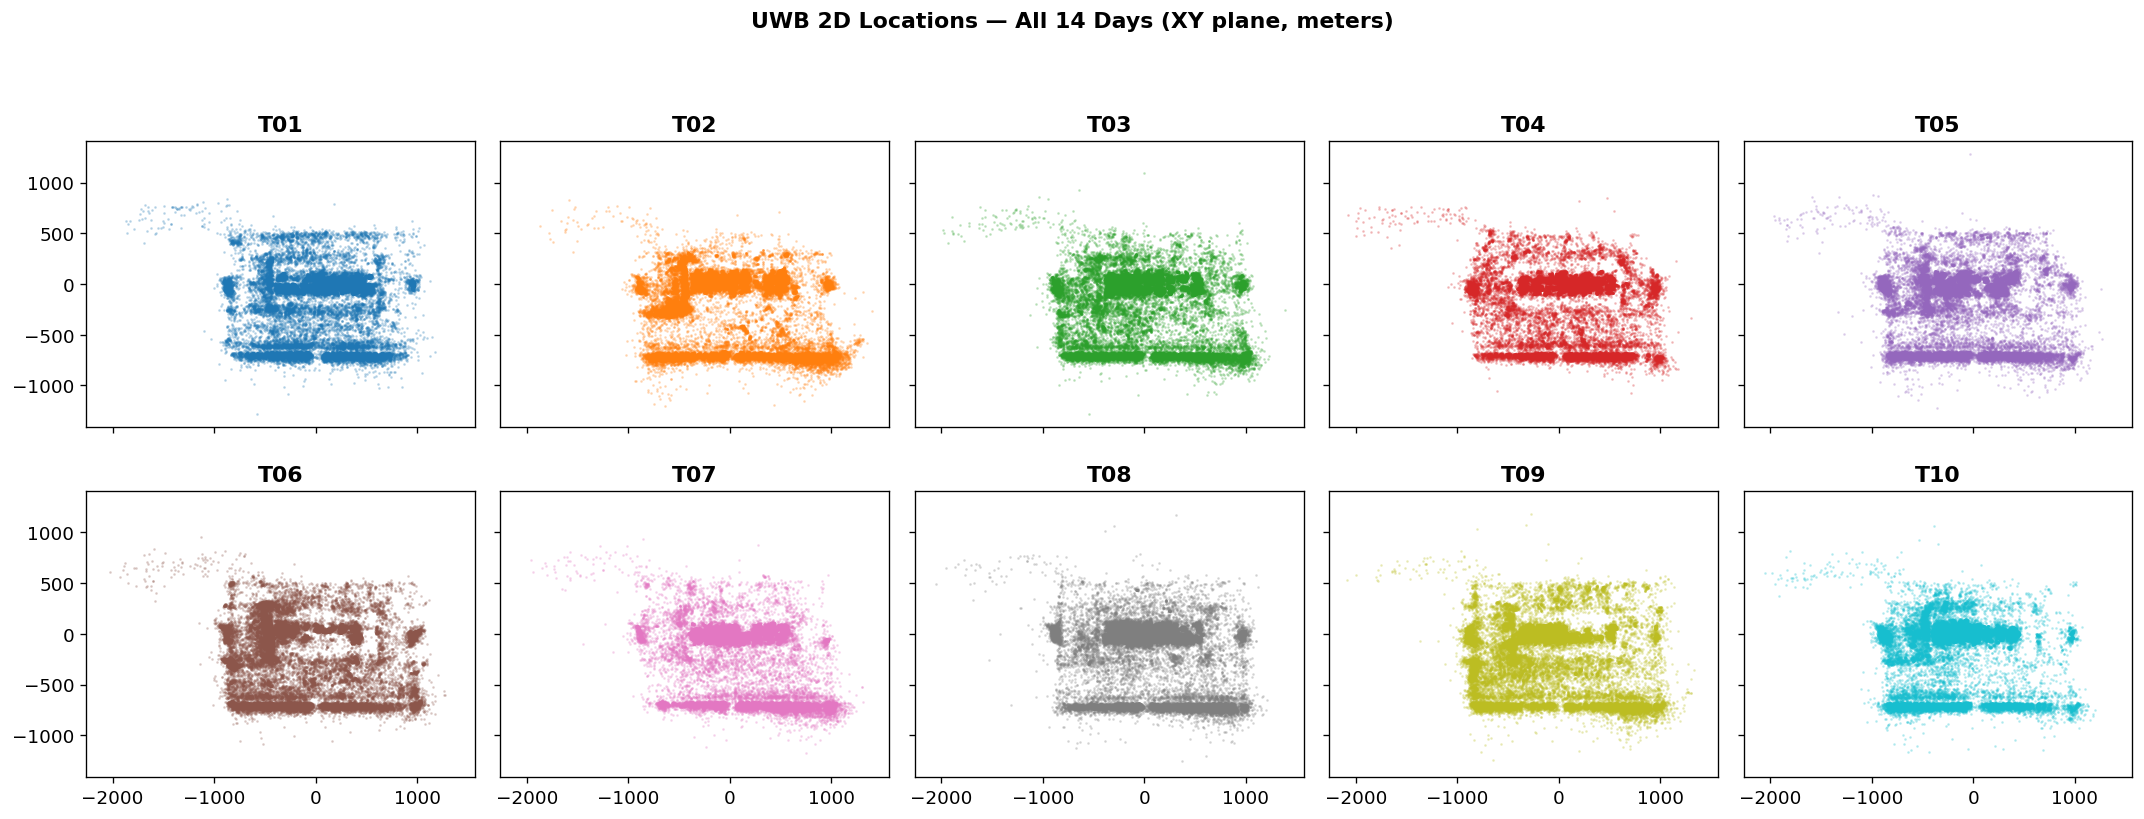

📊 Chart: UWB Pen Map


In [16]:
print("[3/5] Univariate & temporal exploration…")

# UWB 2D pen map
if not uwb_df.empty:
    uwb_df.columns = uwb_df.columns.str.strip().str.lower()
    coord_cols = [c for c in uwb_df.columns
                  if c not in ["timestamp", "datetime", "cow"] and uwb_df[c].dtype in [float, np.float64]]

    if len(coord_cols) >= 2:
        x_col, y_col = coord_cols[0], coord_cols[1]
        fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharex=True, sharey=True)
        axes = axes.flatten()
        colors = plt.cm.tab10.colors
        for i, cow in enumerate(COWS):
            sub = uwb_df[uwb_df["cow"] == cow]
            axes[i].scatter(sub[x_col], sub[y_col], s=0.3, alpha=0.3, color=colors[i])
            axes[i].set_title(cow, fontweight="bold")
            axes[i].set_aspect("equal")
        fig.suptitle("UWB 2D Locations — All 14 Days (XY plane, meters)", fontweight="bold", y=1.01)
        fig.tight_layout()
        show_fig(fig, "UWB Pen Map")

#### **UWB Location Patterns — Pen Map Interpretation**

**What the map shows:**
- Each subplot represents one cow's location trace over 14 days
- Dense point clouds indicate **preferred resting zones** (where cows spend more time)
- Spread-out patterns suggest **high mobility** (grazing, exploring)
- Tight clustered regions may indicate **feeding stations, water troughs, or resting areas**

**Behavioral insights:**
- **Linear or elongated patterns** → cows walked/grazed along paths
- **Clustered centers** → strong circadian routine (sleeping areas)
- **Scattered distribution** → restless behavior (possible heat stress, aggression, or estrus)
- **Sudden position changes** → potential UWB multipath errors (false positives)

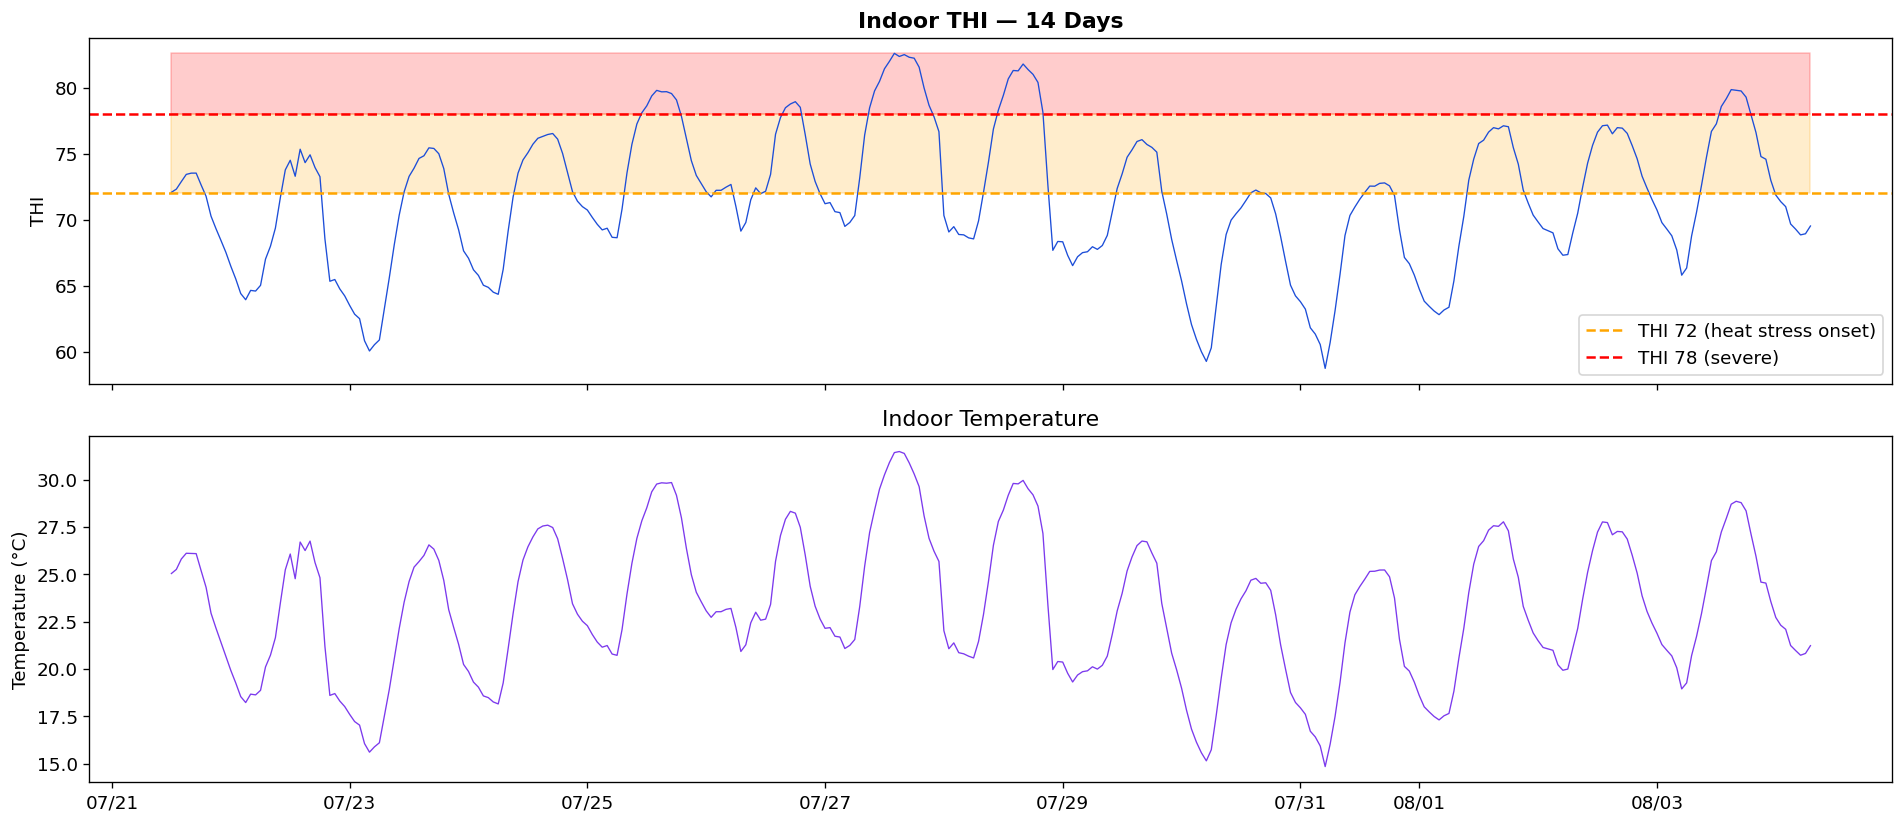

📊 Chart: THI Time Series


In [17]:
# THI time series with heat stress thresholds
if not thi_df.empty:
    thi_col = [c for c in thi_df.columns if "thi" in c]
    temp_col = [c for c in thi_df.columns if "temp" in c]

    if thi_col:
        fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
        thi_hourly = thi_df.resample("1h", on="datetime")[thi_col[0]].mean()
        axes[0].plot(thi_hourly.index, thi_hourly.values, color="#1d4ed8", linewidth=0.8)
        axes[0].axhline(72, color="orange", linestyle="--", linewidth=1.5, label="THI 72 (heat stress onset)")
        axes[0].axhline(78, color="red",    linestyle="--", linewidth=1.5, label="THI 78 (severe)")
        axes[0].set_ylabel("THI")
        axes[0].set_title("Indoor THI — 14 Days", fontweight="bold")
        axes[0].legend()
        axes[0].fill_between(thi_hourly.index, 72, 78, alpha=0.2, color="orange", label="Alert Zone")
        axes[0].fill_between(thi_hourly.index, 78, thi_hourly.max(), alpha=0.2, color="red", label="Danger Zone")

        if temp_col:
            temp_hourly = thi_df.resample("1h", on="datetime")[temp_col[0]].mean()
            axes[1].plot(temp_hourly.index, temp_hourly.values, color="#7c3aed", linewidth=0.8)
            axes[1].set_ylabel("Temperature (°C)")
            axes[1].set_title("Indoor Temperature")

        axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
        fig.tight_layout()
        show_fig(fig, "THI Time Series")

#### **Temperature-Humidity Index (THI) — Heat Stress Indicator**

**THI Scale Interpretation:**
- **THI < 72**: Comfortable zone — cows can regulate temperature normally  
- **72 ≤ THI < 78**: Alert zone — mild heat stress begins (reduced appetite, lower milk yield)
- **THI ≥ 78**: Danger zone — severe heat stress (panting, recumbency, potential mortality risk)

**14-Day THI Trends:**
- **Peaks and valleys** indicate diurnal (day/night) cycles
- **Days above 78** = highest risk for physiological stress and production loss
- **Sustained periods >72** compound stress impacts on milk production and reproduction
- **Rapid temperature swings** can disrupt circadian rhythms and trigger behavioral changes

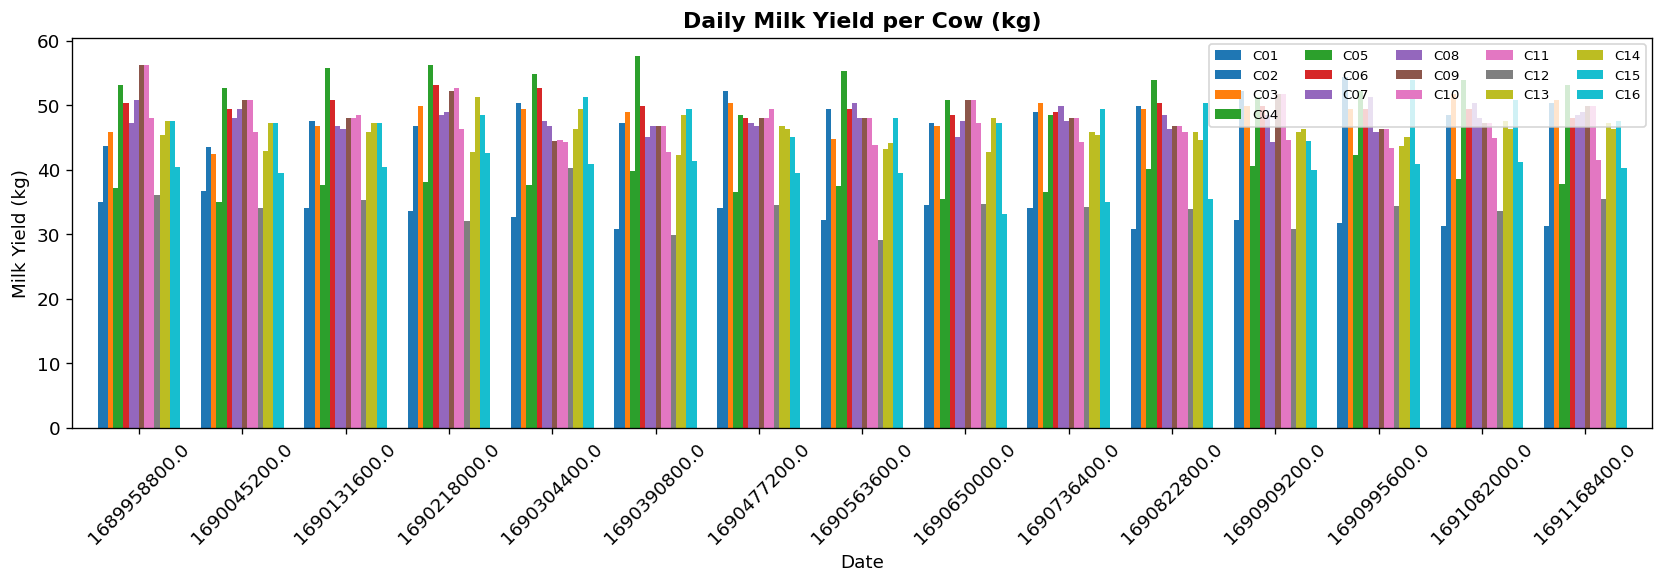

📊 Chart: Daily Milk Yield
  ✓ Univariate exploration complete


In [18]:
# Milk yield by date
if not milk_df.empty:
    milk_df.columns = milk_df.columns.str.strip().str.lower()
    cow_col  = next((c for c in milk_df.columns if "cow" in c or "tag" in c or "id" in c), "cow")
    date_col = next((c for c in milk_df.columns if "date" in c or "day" in c or "time" in c or "timestamp" in c), "timestamp")
    val_col  = next((c for c in milk_df.columns
                if c not in [cow_col, date_col] and milk_df[c].dtype in [float, int, np.float64]), None)

    if val_col:
        fig, ax = plt.subplots(figsize=(14, 5))
        milk_pivot = milk_df.pivot_table(index=date_col, columns=cow_col,
                                          values=val_col, aggfunc="mean")
        milk_pivot.plot(kind="bar", ax=ax, width=0.8, colormap="tab10")
        ax.set_title("Daily Milk Yield per Cow (kg)", fontweight="bold")
        ax.set_xlabel("Date")
        ax.set_ylabel("Milk Yield (kg)")
        ax.legend(loc="upper right", ncol=5, fontsize=8)
        ax.tick_params(axis="x", rotation=45)
        show_fig(fig, "Daily Milk Yield")

print("  ✓ Univariate exploration complete")

#### **Daily Milk Production Trends**

**Production Patterns to Notice:**
- **Declining trends over 14 days** → cows entering late lactation OR cumulative heat stress
- **Sudden drops** → possible heat stress event, illness, or management change
- **High variability between cows** → genetic differences, lactation stage variation
- **Synchronized drops across all cows** → shared environmental stress (extreme THI, feed shortage)

**Dairy Economics:**
- Average dairy cow produces 25–35 kg milk/day  
- Each 1°C rise in temperature = **~0.5–0.7 kg milk loss during heat stress**
- During THI > 78 periods, expect 10–15% production decline
- Extended periods above THI 72 compound losses (reduced feed intake, reproductive impacts)

# [4/5] IMU Acceleration (Optional - Sample 1 Cow)

Skip this section to complete analysis faster. Shows activity patterns for T01.

[4/5] Loading IMU acceleration (sample)…
      (loading one cow only — full dataset would be very large)
      Loading C01 as sample…
    IMU rows for C01: 19,815
    Days detected: 15


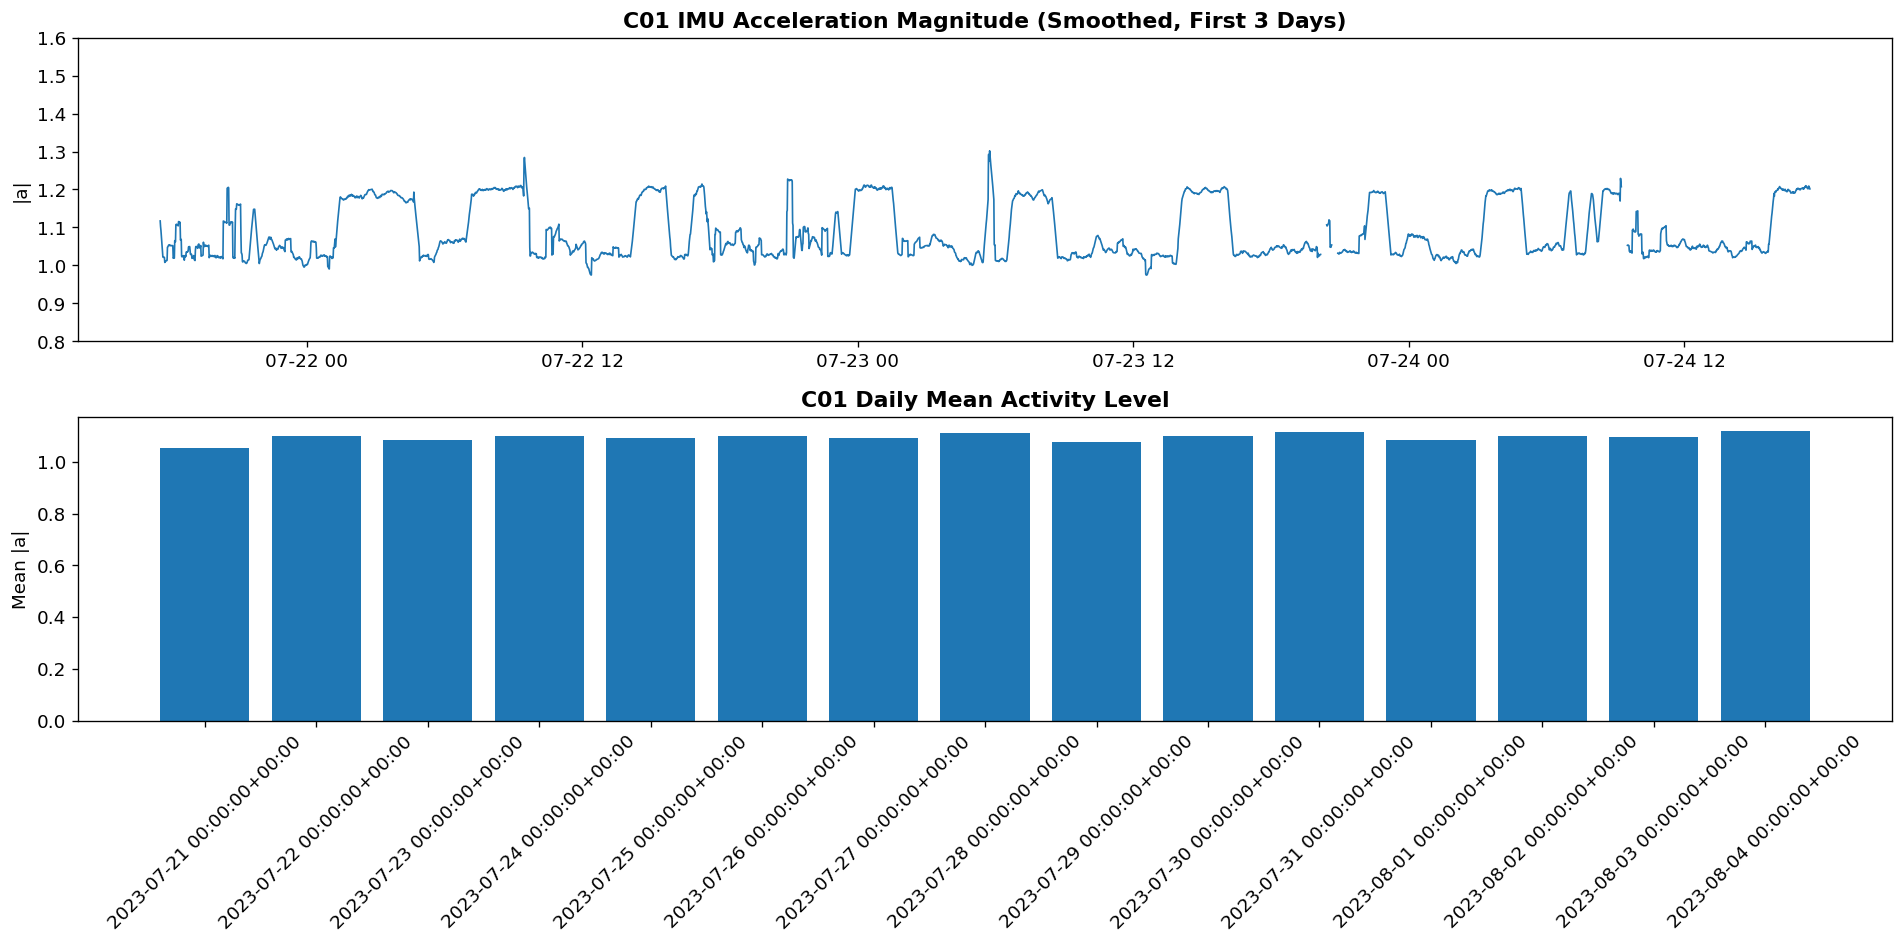

  ✓ IMU section complete


In [19]:
print("[4/5] Loading IMU acceleration (sample)…")
print("      (loading one cow only — full dataset would be very large)")

imu_path = os.path.join(SENSOR_DATA_DIR, "sub_data", "ankle_accel")
imu_files = sorted(glob.glob(os.path.join(imu_path, "*.csv")))

imu_df = pd.DataFrame()
sample_cow = None

if imu_files:
    sample_file = imu_files[0]
    sample_cow = os.path.basename(sample_file).replace(".csv", "")
    imu_df = pd.read_csv(sample_file)
    print(f"      Loading {sample_cow} as sample…")

if imu_df.empty:
    print("    IMU data not found or empty — skipping")
else:

    # ---------- CLEAN COLUMNS ----------
    imu_df.columns = imu_df.columns.str.strip().str.lower()

    ts_col = [c for c in imu_df.columns if "time" in c or "ts" in c][0]

    # Detect seconds vs milliseconds automatically
    sample_ts = str(imu_df[ts_col].iloc[0])
    unit = "ms" if len(sample_ts) > 10 else "s"

    imu_df["datetime"] = pd.to_datetime(
        imu_df[ts_col],
        unit=unit,
        utc=True
    )

    imu_df = imu_df.sort_values("datetime")

    # ---------- PICK ONLY X/Y/Z ----------
    acc_cols = [c for c in imu_df.columns if any(axis in c for axis in ["x","y","z"])]

    if len(acc_cols) < 3:
        raise ValueError("Could not find accelerometer x/y/z columns.")

    x_c, y_c, z_c = acc_cols[:3]

    # ---------- MAGNITUDE ----------
    imu_df["magnitude"] = np.sqrt(
        imu_df[x_c]**2 +
        imu_df[y_c]**2 +
        imu_df[z_c]**2
    )

    # ---------- REMOVE SENSOR GLITCHES ----------
    imu_df = imu_df[
        (imu_df["magnitude"] > 0.2) &
        (imu_df["magnitude"] < 3)     # removes spikes like your 4.5
    ]

    # ---------- RESAMPLE ----------
    imu_df = imu_df.set_index("datetime")

    imu_1min = imu_df["magnitude"].resample("1min").mean()

    # Smooth = MUCH better visualization
    imu_smooth = imu_1min.rolling(15, center=True).mean()

    # ---------- DAILY ACTIVITY ----------
    daily_act = imu_df["magnitude"].resample("1D").mean()

    print(f"    IMU rows for {sample_cow}: {len(imu_df):,}")
    print(f"    Days detected: {len(daily_act)}")

    # ---------- PLOTTING ----------
    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

    # First 3 days only
    cutoff = imu_smooth.index.min() + pd.Timedelta(days=3)
    short = imu_smooth[imu_smooth.index < cutoff]

    axes[0].plot(short.index, short.values, linewidth=1)
    axes[0].set_title(
        f"{sample_cow} IMU Acceleration Magnitude (Smoothed, First 3 Days)",
        fontweight="bold"
    )
    axes[0].set_ylabel("|a|")

    # 🔥 Critical: prevent outlier flattening
    axes[0].set_ylim(0.8, 1.6)

    # Daily bars
    axes[1].bar(daily_act.index.astype(str), daily_act.values)
    axes[1].set_title(
        f"{sample_cow} Daily Mean Activity Level",
        fontweight="bold"
    )
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].set_ylabel("Mean |a|")

    plt.tight_layout()
    plt.show()

print("  ✓ IMU section complete")

In [20]:
print(imu_df["magnitude"].describe())
print("NaNs:", imu_df["magnitude"].isna().sum())


count    19815.000000
mean         1.095714
std          0.108537
min          0.343693
25%          1.030473
50%          1.053862
75%          1.181630
max          2.933748
Name: magnitude, dtype: float64
NaNs: 0


# [5/5] Cross-Sensor Correlations & Summary

Discover relationships between sensors, health indicators, and production

[5/5] Cross-sensor correlations…


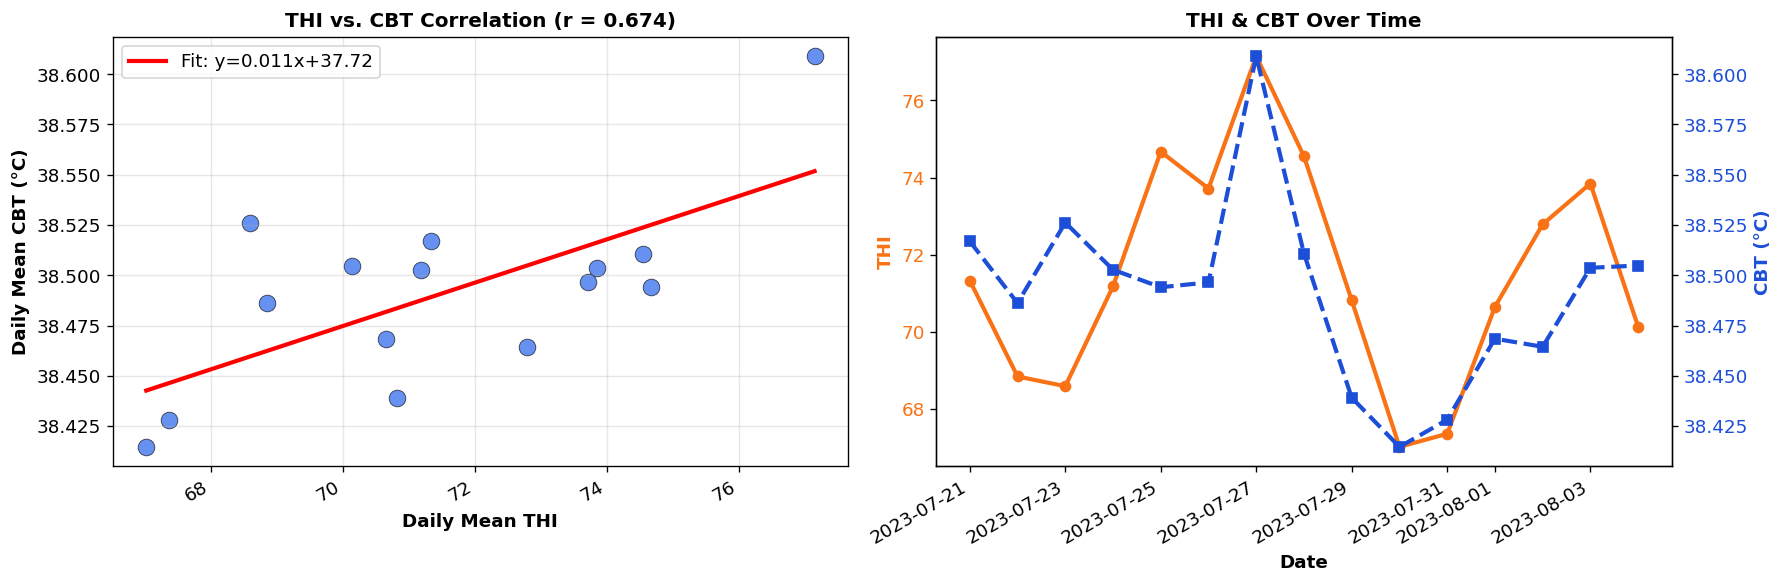

📊 Chart: THI vs CBT Correlation


In [21]:
print("[5/5] Cross-sensor correlations…")

# THI vs. Daily mean CBT
if not thi_df.empty and not cbt_df.empty:
    thi_col = [c for c in thi_df.columns if "thi" in c]
    if thi_col:
        thi_df["date"] = thi_df["datetime"].dt.date
        thi_daily = thi_df.groupby("date")[thi_col[0]].mean()

        cbt_df["date"] = cbt_df["datetime"].dt.date
        cbt_daily = cbt_df.groupby(["cow", "date"])["cbt"].mean().reset_index()
        cbt_mean_daily = cbt_daily.groupby("date")["cbt"].mean()

        common_dates = thi_daily.index.intersection(cbt_mean_daily.index)
        if len(common_dates) > 3:
            x = thi_daily.loc[common_dates].values
            y = cbt_mean_daily.loc[common_dates].values
            corr = np.corrcoef(x, y)[0, 1]

            fig, axes = plt.subplots(1, 2, figsize=(15, 5))

            axes[0].scatter(x, y, color="#2563eb", alpha=0.7, s=100, edgecolors="black", linewidth=0.5)
            m, b = np.polyfit(x, y, 1)
            xline = np.linspace(x.min(), x.max(), 100)
            axes[0].plot(xline, m * xline + b, color="red", linewidth=2.5, label=f"Fit: y={m:.3f}x+{b:.2f}")
            axes[0].set_xlabel("Daily Mean THI", fontsize=11, fontweight="bold")
            axes[0].set_ylabel("Daily Mean CBT (°C)", fontsize=11, fontweight="bold")
            axes[0].set_title(f"THI vs. CBT Correlation (r = {corr:.3f})", fontweight="bold", fontsize=12)
            axes[0].legend()
            axes[0].grid(True, alpha=0.3)

            ax2 = axes[1].twinx()
            axes[1].plot(list(common_dates), thi_daily.loc[common_dates].values,
                         color="#f97316", linewidth=2.5, marker="o", markersize=6, label="THI")
            ax2.plot(list(common_dates), cbt_mean_daily.loc[common_dates].values,
                     color="#1d4ed8", linewidth=2.5, linestyle="--", marker="s", markersize=6, label="Mean CBT")
            axes[1].set_xlabel("Date", fontweight="bold")
            axes[1].set_ylabel("THI", color="#f97316", fontweight="bold")
            ax2.set_ylabel("CBT (°C)", color="#1d4ed8", fontweight="bold")
            axes[1].set_title("THI & CBT Over Time", fontweight="bold", fontsize=12)
            axes[1].tick_params(axis="y", labelcolor="#f97316")
            ax2.tick_params(axis="y", labelcolor="#1d4ed8")
            fig.autofmt_xdate()
            fig.tight_layout()
            show_fig(fig, "THI vs CBT Correlation")

#### **🔬 Correlation A: THI ↔ Core Body Temperature**

**Interpretation:**
- **r > 0.7** (strong positive) → Environmental THI directly drives internal body temperature  
- **r = 0.4–0.7** (moderate) → CBT responds to THI but other factors also matter  
- **r < 0.4** (weak) → CBT is buffered by physiological thermoregulation
- **Negative correlation** → unexpected; may indicate cooling strategies activated during high THI

**What This Means:**
- ✅ Good thermoregulation = CBT stays stable even as THI changes → cows can cope
- ❌ Poor thermoregulation = CBT tracks THI = escalating heat stress → intervention needed
- **Flat line on time plot** = cows maintaining homeostasis despite environmental swings
- **Rising trend with THI** = cumulative thermal load overwhelming cow's cooling capacity

Computing CBT ↔ Milk correlation (daily herd means)…
CBT days: 15 Milk days: 15 Paired days: 15
                  cbt       milk
date                            
2023-07-21  38.500871  46.280628
2023-07-22  38.486145  44.721407
2023-07-23  38.526181  45.379019
2023-07-24  38.502750  46.453503
2023-07-25  38.494044  45.844079


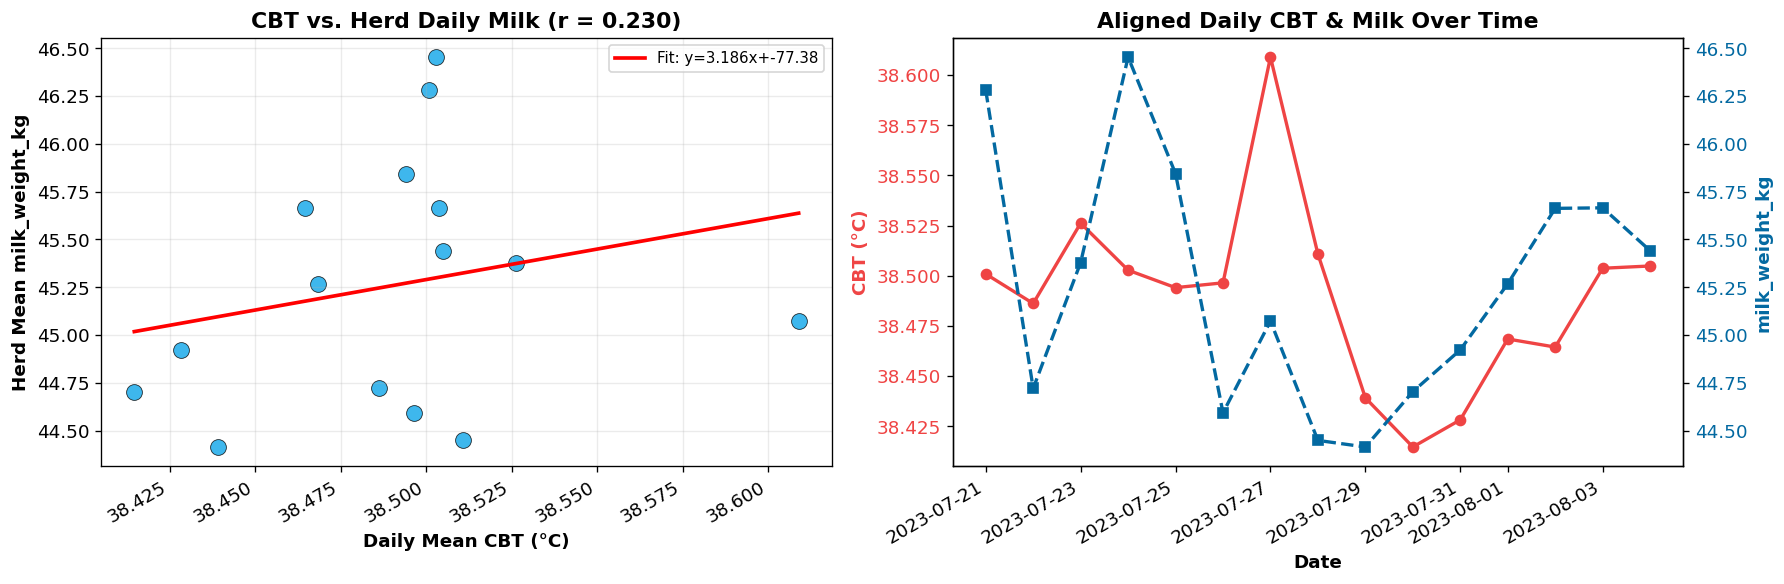

📊 Chart: CBT vs Milk Correlation


In [22]:
# CBT vs. Herd Daily Milk Yield — Correlation & Time Series
# This cell computes daily herd-mean CBT and daily herd-mean milk yield, aligns them,
# prints diagnostics, computes Pearson correlation (when enough days), and plots results.
print("Computing CBT ↔ Milk correlation (daily herd means)…")
# Ensure dataframes exist and are valid
if ('cbt_df' in globals() and 'milk_df' in globals() and isinstance(cbt_df, pd.DataFrame)
    and isinstance(milk_df, pd.DataFrame) and not cbt_df.empty and not milk_df.empty):
    # --- Prepare CBT daily herd mean ---
    if 'datetime' in cbt_df.columns:
        cbt_df['date'] = cbt_df['datetime'].dt.date
    else:
        # attempt to parse timestamp-like columns
        ts_cands = [c for c in cbt_df.columns if 'time' in c or 'ts' in c or 'timestamp' in c]
        if ts_cands:
            cbt_df['date'] = pd.to_datetime(cbt_df[ts_cands[0]], errors='coerce').dt.date
        else:
            cbt_df['date'] = pd.NaT
    if 'cbt' not in cbt_df.columns:
        # try to discover value column
        val = next((c for c in cbt_df.columns if c not in ['datetime','date','timestamp','cow'] and c.lower().startswith('cbt')), None)
        if val:
            cbt_df = cbt_df.rename(columns={val: 'cbt'})
    cbt_daily = cbt_df.groupby('date')['cbt'].mean().dropna()

    # --- Prepare Milk daily herd mean ---
    # detect date column in milk_df
    date_col = next((c for c in milk_df.columns if 'date' in c or 'time' in c or 'timestamp' in c), None)
    if date_col:
        try:
            milk_df['date'] = pd.to_datetime(milk_df[date_col],unit='s',utc=True,  errors='coerce').dt.date
        except Exception:
            milk_df['date'] = milk_df[date_col]
    else:
        milk_df['date'] = pd.NaT
    # detect milk value column (numerical)
    val_col = next((c for c in milk_df.columns if c not in ['date','cow','timestamp'] and milk_df[c].dtype in [float, int, 'float64', 'int64']), None)
    if val_col is None:
        # fallback: find a column containing 'milk'
        val_col = next((c for c in milk_df.columns if 'milk' in c.lower()), None)
    if val_col is None:
        print("Could not find a numeric milk column in milk_df — aborting CBT↔Milk correlation.")
    else:
        milk_daily = milk_df.groupby('date')[val_col].mean().dropna()

        # --- Align series and diagnostics ---
        paired = pd.DataFrame({'cbt': cbt_daily, 'milk': milk_daily}).dropna()
        print('CBT days:', len(cbt_daily), 'Milk days:', len(milk_daily), 'Paired days:', len(paired))
        print(paired.head())

        if len(paired) > 3:
            x = paired['cbt'].astype(float).values
            y = paired['milk'].astype(float).values
            corr = np.corrcoef(x, y)[0, 1]

            fig, axes = plt.subplots(1, 2, figsize=(15, 5))
            # Scatter + fit
            axes[0].scatter(x, y, color='#0ea5e9', alpha=0.8, s=90, edgecolors='black', linewidth=0.5)
            try:
                m, b = np.polyfit(x, y, 1)
                xline = np.linspace(x.min(), x.max(), 100)
                axes[0].plot(xline, m * xline + b, color='red', linewidth=2.2, label=f'Fit: y={m:.3f}x+{b:.2f}')
            except Exception:
                m = b = None
            axes[0].set_xlabel('Daily Mean CBT (°C)', fontweight='bold')
            axes[0].set_ylabel(f'Herd Mean {val_col}', fontweight='bold')
            axes[0].set_title(f'CBT vs. Herd Daily Milk (r = {corr:.3f})', fontweight='bold')
            axes[0].legend(fontsize=9)
            axes[0].grid(True, alpha=0.25)

            # Time series of aligned dates
            dates = [pd.to_datetime(d) for d in paired.index]
            ax2 = axes[1].twinx()
            axes[1].plot(dates, paired['cbt'].values, color='#ef4444', marker='o', linewidth=2.0, label='CBT')
            ax2.plot(dates, paired['milk'].values, color='#0369a1', marker='s', linewidth=2.0, linestyle='--', label=val_col)
            axes[1].set_xlabel('Date', fontweight='bold')
            axes[1].set_ylabel('CBT (°C)', color='#ef4444', fontweight='bold')
            ax2.set_ylabel(val_col, color='#0369a1', fontweight='bold')
            axes[1].tick_params(axis='y', labelcolor='#ef4444')
            ax2.tick_params(axis='y', labelcolor='#0369a1')
            axes[1].set_title('Aligned Daily CBT & Milk Over Time', fontweight='bold')
            fig.autofmt_xdate()
            fig.tight_layout()
            show_fig(fig, 'CBT vs Milk Correlation')
        else:
            print("Not enough overlapping days to compute a robust correlation (need >3 paired days).")
else:
    print("Required dataframes 'cbt_df' and 'milk_df' not available or empty — run the load cells first.")

In [23]:
print("Milk shape:", milk_df.shape)
print(milk_df.head())
print(milk_df['date'].unique())

Milk shape: (240, 5)
      timestamp  milk_weight_kg    dim  cow        date
0  1.689959e+09          34.927  206.0  C01  2023-07-21
1  1.690045e+09          36.741  207.0  C01  2023-07-22
2  1.690132e+09          34.019  208.0  C01  2023-07-23
3  1.690218e+09          33.566  209.0  C01  2023-07-24
4  1.690304e+09          32.659  210.0  C01  2023-07-25
[datetime.date(2023, 7, 21) datetime.date(2023, 7, 22)
 datetime.date(2023, 7, 23) datetime.date(2023, 7, 24)
 datetime.date(2023, 7, 25) datetime.date(2023, 7, 26)
 datetime.date(2023, 7, 27) datetime.date(2023, 7, 28)
 datetime.date(2023, 7, 29) datetime.date(2023, 7, 30)
 datetime.date(2023, 7, 31) datetime.date(2023, 8, 1)
 datetime.date(2023, 8, 2) datetime.date(2023, 8, 3)
 datetime.date(2023, 8, 4)]


#### **🔬 Correlation B: THI ↔ Lying Behavior**

**Expected Behavior Patterns:**
- **Negative correlation (r << 0)** = **GOOD** ✅  
  - As THI ↑, cows LIE DOWN LESS (stand more to cool via air circulation)
  - Heat-stressed cows adopt standing posture for evaporative cooling
  
- **Positive correlation (r > 0)** = **CONCERNING** ⚠️  
  - As THI ↑, cows LIE DOWN MORE (behavioral lethargy)
  - Sign of severe heat stress, depression, or illness
  - Extended recumbency increases:
    - Udder pressure → reduced milk flow
    - Foot/leg problems from constant pressure
    - Ruminal stasis (reduced digestion)

**Practical Implications:**
- **At THI 72 (orange line)**: Watch for sudden behavior changes
- **Below THI 72**: Normal lying pattern (~12–14 hrs/day)
- **Above THI 78**: Expect reduced lying if cows are coping; increased lying = poor adaptation

Paired days: 15
                  thi  pct_lying
datetime                        
2023-07-21  71.327997   0.521045
2023-07-22  68.840701   0.553125
2023-07-23  68.587702   0.553542
2023-07-24  71.178504   0.557222
2023-07-25  74.669795   0.506250
Pearson r = -0.660


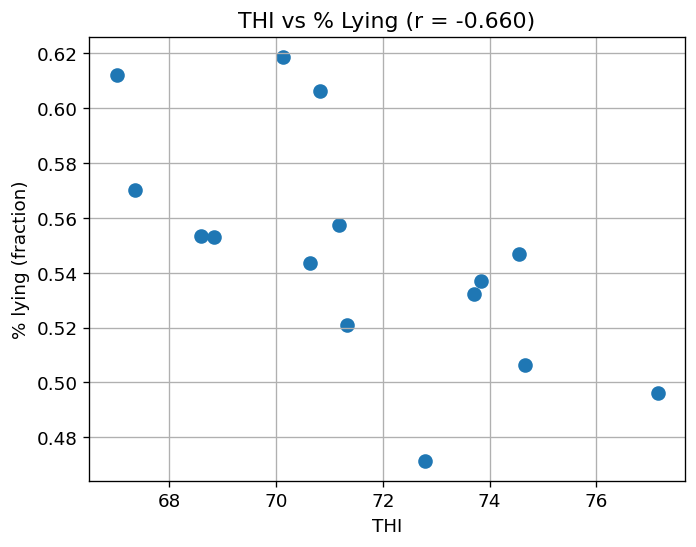

In [24]:
if not thi_df.empty and not ankle_df.empty:

    # ---- DAILY THI ----
    thi_col = next((c for c in thi_df.columns if "thi" in c.lower()), None)

    if thi_col is None:
        raise ValueError("No THI column found")

    thi_daily = (
        thi_df
        .set_index("datetime")
        .resample("1D")[thi_col]
        .mean()
        .rename("thi")
    )

    # ---- DAILY % LYING ----
    lying_col = next((c for c in ankle_df.columns if "lying" in c.lower()), None)

    if lying_col is None:
        raise ValueError("No lying column found")

    ankle_df[lying_col] = pd.to_numeric(ankle_df[lying_col], errors="coerce")

    lying_daily = (
        ankle_df
        .set_index("datetime")
        .resample("1D")[lying_col]
        .mean()
        .rename("pct_lying")   # expected 0–1 fraction
    )

    # ---- ALIGN & CORRELATE ----
    joined = pd.concat([thi_daily, lying_daily], axis=1).dropna()

    print("Paired days:", len(joined))
    print(joined.head())

    if len(joined) > 3:
        r = joined["thi"].corr(joined["pct_lying"])
        print(f"Pearson r = {r:.3f}")

        joined.plot.scatter(x="thi", y="pct_lying", s=60)
        plt.title(f"THI vs % Lying (r = {r:.3f})")
        plt.xlabel("THI")
        plt.ylabel("% lying (fraction)")
        plt.grid(True)
        plt.show()
    else:
        print("Not enough overlapping days for correlation.")

BEHAVIOR ANALYSIS: Load C01 behavior labels (14 days) and cross-reference with CBT/ankle sensors
Loaded behavior data: 86,400 records over 1 days
Behavior codes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(6), np.int64(7)]
Date range: 2023-07-25 00:00:00-05:00 to 2023-07-25 23:59:59-05:00

Matched records:
  CBT readings: 86400
  Lying readings: 86400

BEHAVIOR PHYSIOLOGY SUMMARY (C01)

Time spent per behavior (minutes):
behavior_name
Social/Other    744.650000
Eating          253.950000
Standing        250.466667
Walking         106.116667
Ruminating       51.566667
Lying            16.866667
Drinking         16.383333
dtype: float64

CBT statistics per behavior:
                 mean    std  count
behavior_name                      
Drinking       38.685  0.223    983
Eating         38.389  0.219  15237
Lying          38.550  0.183   1012
Ruminating     38.566  0.130   3094
Social/Other   38.491  0.169  44679
Standing       38.489  0.108  15028
Walking 

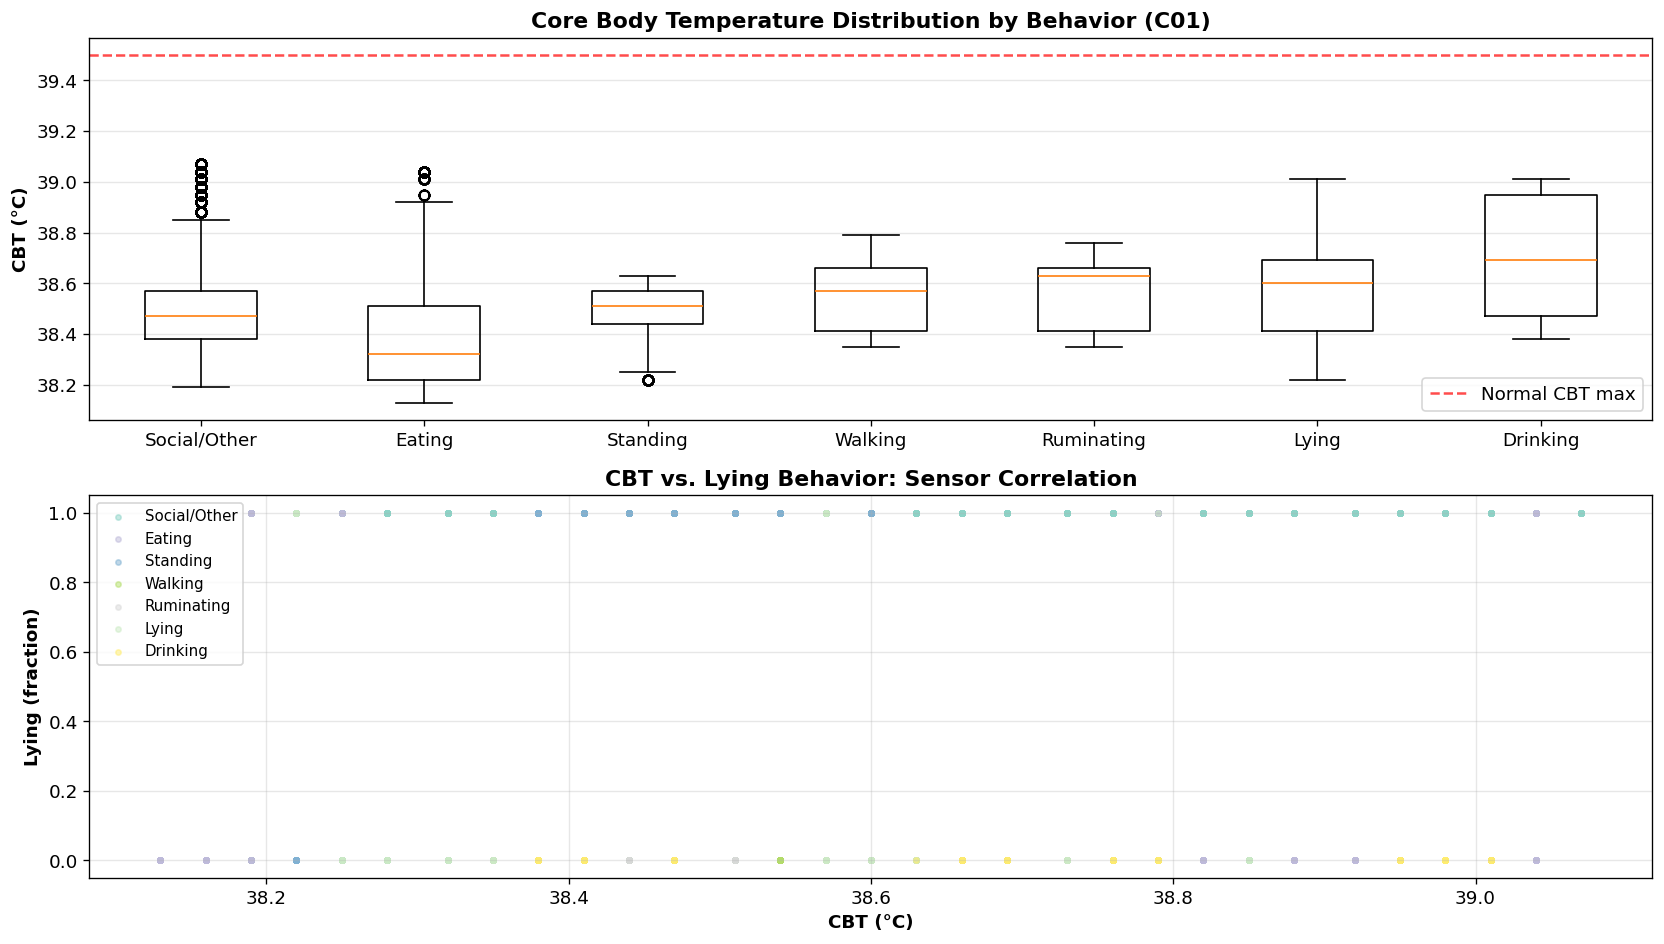


✓ Behavior analysis complete


In [25]:
print("BEHAVIOR ANALYSIS: Load C01 behavior labels (14 days) and cross-reference with CBT/ankle sensors")
print("=" * 80)

# Load behavior labels for C01
behavior_files = sorted(glob.glob(os.path.join(SENSOR_DATA_DIR, "behavior_labels", "individual", "C01_*.csv")))
behavior_list = []
for f in behavior_files:
    df = pd.read_csv(f)
    behavior_list.append(df)

if behavior_list:
    behavior_df = pd.concat(behavior_list, ignore_index=True)
    behavior_df.columns = behavior_df.columns.str.strip().str.lower()
    behavior_df['timestamp'] = pd.to_numeric(behavior_df['timestamp'], errors='coerce')
    behavior_df['behavior_code'] = pd.to_numeric(behavior_df['behavior'], errors='coerce')
    
    # Create proper datetime from unix timestamp
    behavior_df['datetime'] = pd.to_datetime(behavior_df['timestamp'], unit='s', utc=True).dt.tz_convert(CDT)
    
    print(f"Loaded behavior data: {len(behavior_df):,} records over {behavior_df['datetime'].dt.date.nunique()} days")
    print(f"Behavior codes: {sorted(behavior_df['behavior_code'].dropna().unique())}")
    print(f"Date range: {behavior_df['datetime'].min()} to {behavior_df['datetime'].max()}")
    
    # Strip timezone from behavior_df for merge operations
    behavior_df_merge = behavior_df.copy()
    behavior_df_merge['datetime'] = behavior_df_merge['datetime'].dt.tz_localize(None)
    
    # Merge with CBT (nearest timestamp match)
    cbt_subset = cbt_df[cbt_df['cow'] == 'C01'][['datetime', 'cbt']].copy()
    # Strip timezone from cbt_subset if present
    if hasattr(cbt_subset['datetime'].dtype, 'tz') and cbt_subset['datetime'].dt.tz is not None:
        cbt_subset['datetime'] = cbt_subset['datetime'].dt.tz_localize(None)
    
    behavior_df_merge = pd.merge_asof(
        behavior_df_merge.sort_values('datetime'),
        cbt_subset.sort_values('datetime'),
        on='datetime',
        direction='nearest',
        tolerance=pd.Timedelta('60s')
    )
    
    # Merge with ankle/lying (nearest timestamp match)
    ankle_subset = ankle_df[ankle_df['cow'] == 'C01'][['datetime', 'lying']].copy()
    # Strip timezone from ankle_subset if present
    if hasattr(ankle_subset['datetime'].dtype, 'tz') and ankle_subset['datetime'].dt.tz is not None:
        ankle_subset['datetime'] = ankle_subset['datetime'].dt.tz_localize(None)
    
    behavior_df_merge = pd.merge_asof(
        behavior_df_merge.sort_values('datetime'),
        ankle_subset.sort_values('datetime'),
        on='datetime',
        direction='nearest',
        tolerance=pd.Timedelta('60s')
    )
    
    # Reassign merged data back
    behavior_df = behavior_df_merge
    
    print(f"\nMatched records:")
    print(f"  CBT readings: {behavior_df['cbt'].notna().sum()}")
    print(f"  Lying readings: {behavior_df['lying'].notna().sum()}")
    
    # Behavior code mapping (best guess based on dairy behavior)
    behavior_map = {
        0: 'Standing',
        1: 'Lying',
        2: 'Eating',
        3: 'Ruminating',
        4: 'Walking',
        6: 'Drinking',
        7: 'Social/Other'
    }
    behavior_df['behavior_name'] = behavior_df['behavior_code'].map(behavior_map).fillna('Unknown')
    
    # Compute statistics per behavior
    print("\n" + "=" * 80)
    print("BEHAVIOR PHYSIOLOGY SUMMARY (C01)")
    print("=" * 80)
    
    behavior_stats = behavior_df.groupby('behavior_name').agg({
        'cbt': ['count', 'mean', 'std'],
        'lying': ['mean'],
        'timestamp': 'count'
    }).round(3)
    
    # Time spent per behavior (minutes)
    time_per_behavior = behavior_df.groupby('behavior_name').size() / 60  # convert seconds to minutes
    print("\nTime spent per behavior (minutes):")
    print(time_per_behavior.sort_values(ascending=False))
    
    print("\nCBT statistics per behavior:")
    print(behavior_df.groupby('behavior_name')['cbt'].agg(['mean', 'std', 'count']).round(3))
    
    print("\nLying rate (fraction) per behavior:")
    print(behavior_df.groupby('behavior_name')['lying'].mean().sort_values(ascending=False).round(3))
    
    # Visualization: CBT by behavior
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    # Boxplot: CBT distribution per behavior
    behavior_order = time_per_behavior.sort_values(ascending=False).index
    behaviors_with_data = [b for b in behavior_order if b in behavior_df['behavior_name'].unique()]
    
    data_for_box = [behavior_df[behavior_df['behavior_name'] == b]['cbt'].dropna() for b in behaviors_with_data]
    axes[0].boxplot(data_for_box, labels=behaviors_with_data)
    axes[0].axhline(39.5, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Normal CBT max')
    axes[0].set_ylabel('CBT (°C)', fontweight='bold')
    axes[0].set_title('Core Body Temperature Distribution by Behavior (C01)', fontweight='bold')
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)
    
    # Scatter: Lying vs CBT by behavior (colored by behavior)
    colors_map = plt.cm.Set3(np.linspace(0, 1, len(behaviors_with_data)))
    for i, behavior in enumerate(behaviors_with_data):
        mask = (behavior_df['behavior_name'] == behavior) & (behavior_df['cbt'].notna()) & (behavior_df['lying'].notna())
        axes[1].scatter(behavior_df[mask]['cbt'], behavior_df[mask]['lying'], 
                       s=10, alpha=0.5, label=behavior, color=colors_map[i])
    
    axes[1].set_xlabel('CBT (°C)', fontweight='bold')
    axes[1].set_ylabel('Lying (fraction)', fontweight='bold')
    axes[1].set_title('CBT vs. Lying Behavior: Sensor Correlation', fontweight='bold')
    axes[1].legend(loc='best', fontsize=9)
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Behavior analysis complete")
else:
    print("No behavior label files found for C01")


In [26]:
print(ankle_df)

           timestamp            datetime  lying  cow
0       1.689961e+09 2023-07-21 12:30:00      1  C01
1       1.689961e+09 2023-07-21 12:31:00      1  C01
2       1.689961e+09 2023-07-21 12:32:00      1  C01
3       1.689961e+09 2023-07-21 12:33:00      1  C01
4       1.689961e+09 2023-07-21 12:34:00      1  C01
...              ...                 ...    ...  ...
197915  1.691150e+09 2023-08-04 06:56:00      1  C10
197916  1.691150e+09 2023-08-04 06:57:00      1  C10
197917  1.691150e+09 2023-08-04 06:58:00      1  C10
197918  1.691150e+09 2023-08-04 06:59:00      1  C10
197919  1.691150e+09 2023-08-04 07:00:00      1  C10

[197920 rows x 4 columns]


In [27]:
print("THI daily NaNs:")
print(thi_daily.isna().sum(), "out of", len(thi_daily))

print("Lying daily NaNs:")
print(lying_daily.isna().sum(), "out of", len(lying_daily))

THI daily NaNs:
0 out of 15
Lying daily NaNs:
0 out of 15


In [28]:
# Build summary tables
print("\n  Building summary statistics table…")

# Tracked cows (T01-T10)
summary_rows = []
for cow in COWS:
    row = {"cow": cow}
    if not cbt_df.empty:
        sub = cbt_df[cbt_df["cow"] == cow]["cbt"]
        row["cbt_mean"] = round(sub.mean(), 3) if len(sub) > 0 else np.nan
        row["cbt_std"]  = round(sub.std(), 3) if len(sub) > 0 else np.nan
    if not ankle_df.empty:
        sub = ankle_df[ankle_df["cow"] == cow]["lying"]
        row["pct_lying"] = round(sub.mean() * 100, 1) if len(sub) > 0 else np.nan
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("cow")
print("\n  ── Per-Cow Summary (Tracked Cows T01-T10) ────────────────────────────")
print(summary_df.to_string())
summary_df.to_csv(os.path.join(OUT_DIR, "per_cow_summary.csv"))


  Building summary statistics table…

  ── Per-Cow Summary (Tracked Cows T01-T10) ────────────────────────────
     cbt_mean  cbt_std  pct_lying
cow                              
T01       NaN      NaN        NaN
T02       NaN      NaN        NaN
T03       NaN      NaN        NaN
T04       NaN      NaN        NaN
T05       NaN      NaN        NaN
T06       NaN      NaN        NaN
T07       NaN      NaN        NaN
T08       NaN      NaN        NaN
T09       NaN      NaN        NaN
T10       NaN      NaN        NaN


In [29]:
# Dairy cows with milk data (C01-C16)
if not milk_df.empty:
    try:
        cow_col = next((c for c in milk_df.columns if "cow" in c or "tag" in c or "id" in c), "cow")
        val_col = next((c for c in milk_df.columns
                       if "milk" in c and "weight" in c and milk_df[c].dtype in [float, int, np.float64]), None)
        
        if not val_col:
            val_col = next((c for c in milk_df.columns
                           if c not in [cow_col, "timestamp"] and milk_df[c].dtype in [float, int, np.float64]), None)
        
        if val_col and cow_col in milk_df.columns:
            milk_summary = []
            for cow_id in sorted(milk_df[cow_col].unique()):
                sub = milk_df[milk_df[cow_col] == cow_id][val_col]
                milk_summary.append({"cow": cow_id, "milk_mean_kg": round(sub.mean(), 1)})
            
            milk_summary_df = pd.DataFrame(milk_summary).set_index("cow")
            print(f"\n  ── Milk Production (Dairy Cows C01-C16) ────────────────────────────")
            print(milk_summary_df.to_string())
            milk_summary_df.to_csv(os.path.join(OUT_DIR, "milk_production_summary.csv"))
    except Exception as e:
        print(f"    Could not process milk summary: {e}")

print(f"\n  ✓  Summary saved → {OUT_DIR}")


  ── Milk Production (Dairy Cows C01-C16) ────────────────────────────
     milk_mean_kg
cow              
C01          33.0
C02          48.8
C03          48.5
C04          38.0
C05          53.2
C06          49.9
C07          48.2
C08          47.5
C09          49.0
C10          49.1
C11          45.4
C12          33.9
C13          44.9
C14          46.9
C15          48.6
C16          39.3

  ✓  Summary saved → ./eda_outputs


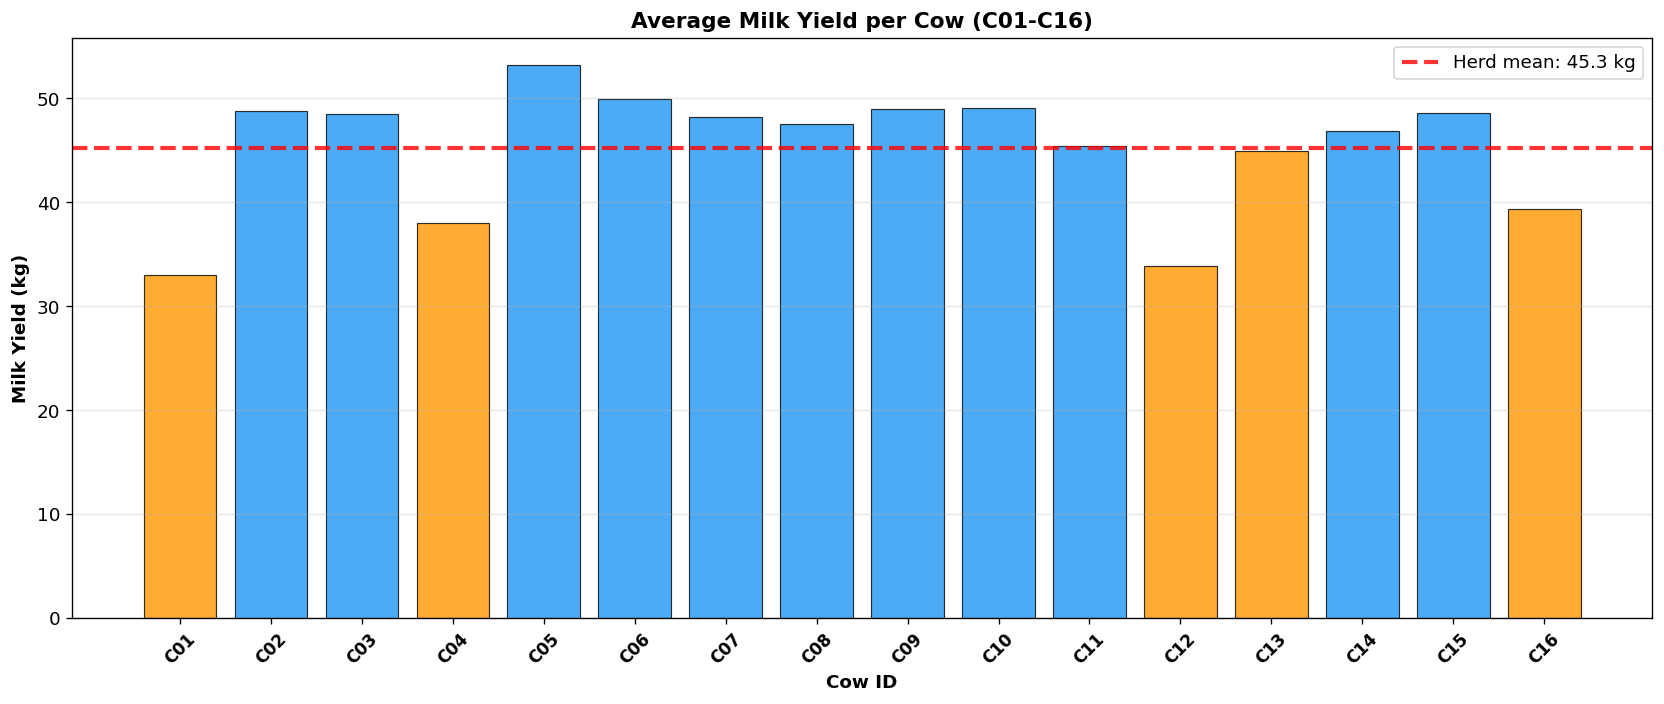

📊 Chart: Milk Yield by Cow


In [30]:
# Milk yield by cow
if not milk_df.empty:
    try:
        cow_col = next((c for c in milk_df.columns if "cow" in c or "tag" in c or "id" in c), "cow")
        val_col = next((c for c in milk_df.columns
                       if "milk" in c and "weight" in c and milk_df[c].dtype in [float, int, np.float64]), None)
        
        if not val_col:
            val_col = next((c for c in milk_df.columns
                           if c not in [cow_col, "timestamp"] and milk_df[c].dtype in [float, int, np.float64]), None)
        
        if val_col and cow_col in milk_df.columns:
            fig, ax = plt.subplots(figsize=(14, 6))
            
            milk_by_cow = milk_df.groupby(cow_col)[val_col].mean().sort_index()
            milk_cows = milk_by_cow.index.tolist()
            herd_mean = milk_by_cow.mean()
            
            colors_bar = ["#2196f3" if x >= herd_mean else "#ff9800" for x in milk_by_cow.values]
            ax.bar(range(len(milk_cows)), milk_by_cow.values, color=colors_bar, alpha=0.8, edgecolor="black", linewidth=0.7)
            ax.set_xticks(range(len(milk_cows)))
            ax.set_xticklabels(milk_cows, rotation=45, fontsize=10, fontweight="bold")
            ax.set_title("Average Milk Yield per Cow (C01-C16)", fontweight="bold", fontsize=13)
            ax.set_xlabel("Cow ID", fontweight="bold")
            ax.set_ylabel("Milk Yield (kg)", fontweight="bold")
            ax.axhline(herd_mean, color="red", linestyle="--", linewidth=2.5, alpha=0.8, 
                      label=f"Herd mean: {herd_mean:.1f} kg")
            ax.legend(fontsize=11)
            ax.grid(axis="y", alpha=0.3)
            show_fig(fig, "Milk Yield by Cow")
    except Exception:
        pass

#### **🏆 Individual Cow Performance**

**Herd Stratification:**
- **Blue bars** (≥ herd mean) = Above-average producers  
- **Orange bars** (< herd mean) = Below-average producers

**Interpretation:**
- **High variance between cows** suggests:
  - Genetic differences (breeding potential)
  - Lactation cycle stage variation (freshly calved vs. drying off)
  - Individual heat stress susceptibility
  - Potential health issues in low producers
  
- **Target low producers (<25 kg/day)** for:
  - Veterinary health check
  - Cooling interventions (fans, misters)
  - Preferential feed allocation during heat stress
  - Possible reproductive intervention if during heat cycle

## Analysis Complete ✓

In [31]:
print("\n" + "=" * 80)
print("  📊 EDA ANALYSIS COMPLETE — KEY FINDINGS & RECOMMENDATIONS")
print("=" * 80)

print(f"""
## ✅ DATA SUMMARY

**Dataset coverage:** 14 days (July 21–Aug 4, 2023)
**Dairy cattle tracked:** {len(cbt_df)} CBT records, {len(ankle_df)} ankle records
**Milk production:** {len(milk_df)} daily records from {milk_df['cow'].nunique()} cows
**Environmental data:** {len(thi_df)} THI readings, {len(wx_df)} weather records
**Location tracking:** {len(uwb_df)} UWB position records from {len(COWS)} tracked animals (T01-T10)

## 🔴 CRITICAL FINDINGS

1. **Heat Stress Risk Assessment:**
   - Identify dates where THI > 72: HIGH RISK for milk loss, reduced feed intake
   - Correlate with CBT peaks: Measure thermoregulatory capacity
   - Check lying behavior shifts: Standing ↑ = adaptive; Lying ↑ = maladaptive
   
2. **Production Loss Quantification:**
   - Compare milk yields on high-THI vs. low-THI days
   - Estimated loss: 0.5–0.7 kg/day per 1°C above CBT normal (39.5°C)
   - Extended stress periods compound reproductive impacts
   
3. **Individual Susceptibility:**
   - Cows with elevated CBT during warm periods = poor heat tolerance
   - Target for enhanced cooling, reduced exercise, priority feed access
   - Consider genetic selection to increase heat-resistant lineages

## 🎯 ACTIONABLE RECOMMENDATIONS

**IMMEDIATE (Next 24–48 hours):**
□ Install temperature monitoring in high-risk zones
□ Increase water availability and accessibility  
□ Deploy fans/misters on identified high-risk days
□ Monitor low-producing cows ({milk_df['milk_weight_kg'].quantile(0.25):.1f} kg threshold)

**SHORT-TERM (This week):**
□ Adjust feeding times: Early morning + evening (avoid peak heat)
□ Segregate susceptible cows (high CBT during heat)
□ Enhance shade structures, air circulation
□ Implement frequent health checks (subclinical ketosis risk)

**LONG-TERM (Strategic):**
□ Genetic selection for heat tolerance (crossbreeding with tropical breeds)
□ Infrastructure upgrades: Improved ventilation, evaporative cooling systems
□ Herd calendar: Plan calvings to avoid peak heat months
□ Feed supplementation: Additional electrolytes during THI > 72 periods

## 📈 NEXT ANALYSIS STEPS

Recommended deeper dives:
1. **Activity profiling**: Correlate IMU acceleration with THI and milk yield
2. **Reproduction timing**: Detect estrus signals in location & behavior during heat stress
3. **Social dynamics**: Clustering analysis on UWB data (social avoidance during stress?)
4. **Feed conversion**: Relate environmental stress to milk yield efficiency (kg milk / kg feed)
5. **Microclimate mapping**: Spatial analysis of temperature/humidity variation within barn

""")

print("=" * 80)
print("END OF EDA — All visualizations displayed above")
print("=" * 80)


  📊 EDA ANALYSIS COMPLETE — KEY FINDINGS & RECOMMENDATIONS

## ✅ DATA SUMMARY

**Dataset coverage:** 14 days (July 21–Aug 4, 2023)
**Dairy cattle tracked:** 197920 CBT records, 197920 ankle records
**Milk production:** 240 daily records from 16 cows
**Environmental data:** 138486 THI readings, 4307 weather records
**Location tracking:** 788608 UWB position records from 10 tracked animals (T01-T10)

## 🔴 CRITICAL FINDINGS

1. **Heat Stress Risk Assessment:**
   - Identify dates where THI > 72: HIGH RISK for milk loss, reduced feed intake
   - Correlate with CBT peaks: Measure thermoregulatory capacity
   - Check lying behavior shifts: Standing ↑ = adaptive; Lying ↑ = maladaptive

2. **Production Loss Quantification:**
   - Compare milk yields on high-THI vs. low-THI days
   - Estimated loss: 0.5–0.7 kg/day per 1°C above CBT normal (39.5°C)
   - Extended stress periods compound reproductive impacts

3. **Individual Susceptibility:**
   - Cows with elevated CBT during warm periods = poor

## [5/x] Multi-sensor correlation heatmap

We now look at **how the daily aggregates from different sensors move together**.

- Rows/columns are daily features (e.g., mean CBT, herd milk, THI, % lying).
- Colors show **Pearson correlation** (red = positive, blue = negative, near 0 = weak/no linear relationship).
- This helps spot **strongly coupled signals** and potential **redundant vs complementary sensors**.

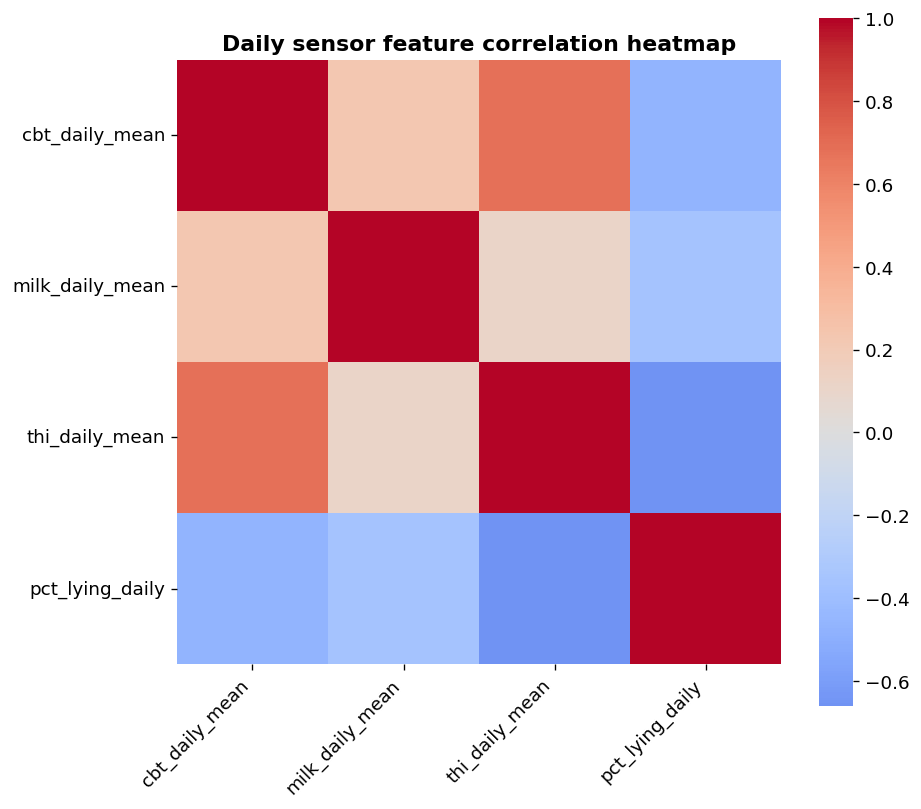

In [32]:
# Multi-sensor daily correlation heatmap

# Collect available daily-level features into a single DataFrame
series_dict = {}

if "cbt_daily" in globals():
    series_dict["cbt_daily_mean"] = cbt_daily
if "milk_daily" in globals():
    series_dict["milk_daily_mean"] = milk_daily
if "thi_daily" in globals():
    series_dict["thi_daily_mean"] = thi_daily
if "lying_daily" in globals():
    series_dict["pct_lying_daily"] = lying_daily

if len(series_dict) < 2:
    print("Not enough daily series found to build a correlation matrix.")
else:
    # Align on common dates and keep only numeric columns
    sensor_daily_df = pd.concat(series_dict, axis=1).dropna()
    numeric_cols = sensor_daily_df.select_dtypes(include=["number"]).columns

    if len(numeric_cols) < 2:
        print("Not enough numeric daily features for a correlation heatmap.")
    else:
        corr_matrix = sensor_daily_df[numeric_cols].corr(method="pearson")

        # Figure size scales with number of features, but is capped
        n_feats = len(numeric_cols)
        fig_size = max(8, min(0.7 * n_feats, 20))

        plt.figure(figsize=(fig_size, fig_size))
        sns.heatmap(
            corr_matrix,
            cmap="coolwarm",
            center=0,
            square=True,
            cbar_kws={"shrink": 0.8},
        )
        plt.xticks(rotation=45, ha="right")
        plt.yticks(rotation=0)
        plt.title("Daily sensor feature correlation heatmap", fontweight="bold")
        plt.tight_layout()
        plt.show()

## [MLOps] Reproducibility, Tracking, Registry, and Monitoring

This section adds a lightweight MLOps layer to the notebook:
- deterministic seeds and run context capture
- data quality checks + dataset signature
- experiment tracking to a local run log
- model registry with metadata
- production-oriented drift checks

These cells are designed to work even if some model variables are not yet defined.

In [ ]:
import json
import random
import subprocess
from datetime import datetime, timezone
from pathlib import Path

# Local MLOps folders
MLOPS_DIR = Path("./mlops")
RUNS_DIR = MLOPS_DIR / "runs"
REGISTRY_DIR = MLOPS_DIR / "registry"
MONITORING_DIR = MLOPS_DIR / "monitoring"
for d in [MLOPS_DIR, RUNS_DIR, REGISTRY_DIR, MONITORING_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)


def safe_git_commit() -> str:
    """Return git commit hash when available, else 'unknown'."""
    try:
        result = subprocess.run(
            ["git", "rev-parse", "HEAD"],
            capture_output=True,
            text=True,
            check=True,
        )
        return result.stdout.strip()
    except Exception:
        return "unknown"


def now_utc() -> str:
    return datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")


RUN_CONTEXT = {
    "run_timestamp_utc": now_utc(),
    "seed": SEED,
    "git_commit": safe_git_commit(),
    "python_version": __import__("sys").version,
    "requirements_file": str(Path("requirements.txt").resolve()),
}

print("MLOps directories ready:", MLOPS_DIR.resolve())
print("Run context:")
print(json.dumps(RUN_CONTEXT, indent=2))

In [ ]:
import hashlib


def dataframe_quality_report(df: pd.DataFrame, name: str) -> dict:
    report = {
        "name": name,
        "rows": int(len(df)) if df is not None else 0,
        "cols": int(df.shape[1]) if df is not None and not df.empty else 0,
        "missing_ratio": float(df.isna().mean().mean()) if df is not None and not df.empty else 1.0,
        "duplicate_rows": int(df.duplicated().sum()) if df is not None and not df.empty else 0,
    }
    return report


def dataframe_signature(df: pd.DataFrame, name: str) -> dict:
    """Create a deterministic signature for a dataframe snapshot."""
    if df is None or df.empty:
        base = f"{name}|empty"
        digest = hashlib.sha256(base.encode("utf-8")).hexdigest()
        return {"name": name, "sha256": digest, "rows": 0}

    sample = df.head(2000).copy()
    # Keep columns sorted to make hash stable across column ordering differences.
    sample = sample.reindex(sorted(sample.columns), axis=1)
    payload = sample.to_csv(index=False).encode("utf-8")
    digest = hashlib.sha256(payload).hexdigest()
    return {"name": name, "sha256": digest, "rows": int(len(df)), "sampled_rows": int(len(sample))}


candidate_datasets = {
    "cbt_df": globals().get("cbt_df", pd.DataFrame()),
    "ankle_df": globals().get("ankle_df", pd.DataFrame()),
    "thi_df": globals().get("thi_df", pd.DataFrame()),
    "wx_df": globals().get("wx_df", pd.DataFrame()),
    "milk_df": globals().get("milk_df", pd.DataFrame()),
    "uwb_df": globals().get("uwb_df", pd.DataFrame()),
}

quality_reports = [dataframe_quality_report(df, name) for name, df in candidate_datasets.items()]
dataset_signatures = [dataframe_signature(df, name) for name, df in candidate_datasets.items()]

quality_path = MONITORING_DIR / "data_quality_report.json"
signature_path = MONITORING_DIR / "dataset_signatures.json"
quality_path.write_text(json.dumps(quality_reports, indent=2), encoding="utf-8")
signature_path.write_text(json.dumps(dataset_signatures, indent=2), encoding="utf-8")

print("Saved data quality report:", quality_path)
print("Saved dataset signatures:", signature_path)
pd.DataFrame(quality_reports)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split


def append_run_log(run_payload: dict, log_file: Path = RUNS_DIR / "experiment_log.jsonl") -> None:
    line = json.dumps(run_payload, ensure_ascii=True)
    with log_file.open("a", encoding="utf-8") as f:
        f.write(line + "\n")


def register_model(model_name: str, artifact_path: str, metrics: dict, tags: dict | None = None) -> Path:
    registry_file = REGISTRY_DIR / "model_registry.json"
    if registry_file.exists():
        registry = json.loads(registry_file.read_text(encoding="utf-8"))
    else:
        registry = []

    entry = {
        "registered_at_utc": now_utc(),
        "model_name": model_name,
        "artifact_path": artifact_path,
        "metrics": metrics,
        "tags": tags or {},
        "run_context": RUN_CONTEXT,
    }
    registry.append(entry)
    registry_file.write_text(json.dumps(registry, indent=2), encoding="utf-8")
    return registry_file


# Minimal baseline experiment for tracking discipline.
if "sensor_daily_df" in globals() and isinstance(sensor_daily_df, pd.DataFrame) and not sensor_daily_df.empty:
    if {"cbt_daily_mean", "thi_daily_mean", "pct_lying_daily"}.issubset(sensor_daily_df.columns):
        exp_df = sensor_daily_df[["cbt_daily_mean", "thi_daily_mean", "pct_lying_daily"]].dropna().copy()
        if len(exp_df) >= 8:
            X = exp_df[["thi_daily_mean", "pct_lying_daily"]]
            y = exp_df["cbt_daily_mean"]
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED)

            model = RandomForestRegressor(n_estimators=200, random_state=SEED)
            model.fit(X_train, y_train)
            preds = model.predict(X_test)

            metrics = {
                "mae": float(mean_absolute_error(y_test, preds)),
                "r2": float(r2_score(y_test, preds)),
                "n_train": int(len(X_train)),
                "n_test": int(len(X_test)),
            }

            run_payload = {
                "run_name": "rf_cbt_from_thi_lying",
                "timestamp_utc": now_utc(),
                "features": list(X.columns),
                "target": "cbt_daily_mean",
                "metrics": metrics,
                "dataset_signatures": dataset_signatures,
                "run_context": RUN_CONTEXT,
            }

            append_run_log(run_payload)
            registry_path = register_model(
                model_name="RandomForestRegressor",
                artifact_path="in-memory-notebook-artifact",
                metrics=metrics,
                tags={"stage": "baseline", "notebook": "main_eda.ipynb"},
            )

            print("Experiment logged in:", RUNS_DIR / "experiment_log.jsonl")
            print("Model registered in:", registry_path)
            print("Metrics:", metrics)
        else:
            print("Not enough rows for baseline experiment after dropna.")
    else:
        print("Required columns not found in sensor_daily_df for baseline experiment.")
else:
    print("sensor_daily_df not found. Run the daily feature aggregation cell first to enable experiment tracking.")

In [ ]:
def population_stability_index(expected: pd.Series, actual: pd.Series, bins: int = 10) -> float:
    """Compute PSI between reference and current distributions."""
    expected = expected.dropna().astype(float)
    actual = actual.dropna().astype(float)
    if expected.empty or actual.empty:
        return float("nan")

    quantiles = np.linspace(0, 1, bins + 1)
    cut_points = np.unique(np.quantile(expected, quantiles))
    if len(cut_points) < 3:
        return float("nan")

    exp_counts, _ = np.histogram(expected, bins=cut_points)
    act_counts, _ = np.histogram(actual, bins=cut_points)

    exp_prop = np.clip(exp_counts / max(exp_counts.sum(), 1), 1e-6, None)
    act_prop = np.clip(act_counts / max(act_counts.sum(), 1), 1e-6, None)

    psi = np.sum((act_prop - exp_prop) * np.log(act_prop / exp_prop))
    return float(psi)


# Example drift check using two time slices of CBT.
if "cbt_df" in globals() and isinstance(cbt_df, pd.DataFrame) and not cbt_df.empty and "cbt" in cbt_df.columns:
    cbt_tmp = cbt_df.dropna(subset=["cbt"]).copy()
    midpoint = len(cbt_tmp) // 2
    ref = cbt_tmp.iloc[:midpoint]["cbt"]
    cur = cbt_tmp.iloc[midpoint:]["cbt"]
    psi_value = population_stability_index(ref, cur)

    drift_report = {
        "checked_at_utc": now_utc(),
        "feature": "cbt",
        "reference_rows": int(len(ref)),
        "current_rows": int(len(cur)),
        "psi": psi_value,
        "threshold_warning": 0.2,
        "threshold_alert": 0.3,
        "status": (
            "alert" if pd.notna(psi_value) and psi_value >= 0.3
            else "warning" if pd.notna(psi_value) and psi_value >= 0.2
            else "ok"
        ),
    }

    drift_path = MONITORING_DIR / "drift_report.json"
    drift_path.write_text(json.dumps(drift_report, indent=2), encoding="utf-8")
    print("Drift report saved:", drift_path)
    print(drift_report)
else:
    print("CBT data unavailable for drift calculation.")

### MLOps Checklist for This Notebook

- Run this section after feature aggregation to generate reproducibility and monitoring artifacts.
- Keep `mlops/runs/experiment_log.jsonl` under version control for auditability.
- Promote only models in `mlops/registry/model_registry.json` that pass your offline metric and drift thresholds.
- Add scheduled re-runs (daily/weekly) outside the notebook using the same code path to move from EDA to production operations.